In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_excel("../DataSet/Superstore.xls")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2023-01-03,2023-01-07
1,2023-01-04,2023-01-08
2,2023-01-04,2023-01-08
3,2023-01-04,2023-01-08
4,2023-01-05,2023-01-12


In [5]:
print(df["Order Date"].min())
print(df["Order Date"].max())

2023-01-03 00:00:00
2026-12-30 00:00:00


In [6]:
print(df["Ship Date"].min())
print(df["Ship Date"].max())

2023-01-07 00:00:00
2027-01-05 00:00:00


In [7]:
df["Year"] = df["Order Date"].dt.year

In [8]:
df["Year"].value_counts().sort_index()

Year
2023    2051
2024    2130
2025    2634
2026    3379
Name: count, dtype: int64

In [9]:
df["Month"] = df["Order Date"].dt.month

In [10]:
df["Month"].value_counts().sort_index()

Month
1      404
2      300
3      711
4      670
5      758
6      725
7      718
8      722
9     1399
10     843
11    1474
12    1470
Name: count, dtype: int64

In [11]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [12]:
df[["Order Date", "Year", "Month", "Month Name"]].head()

,Order Date,Year,Month,Month Name
0,2023-01-03,2023,1,January
1,2023-01-04,2023,1,January
2,2023-01-04,2023,1,January
3,2023-01-04,2023,1,January
4,2023-01-05,2023,1,January


In [13]:
df["Quarter"] = df["Order Date"].dt.quarter

In [14]:
df[["Order Date", "Year", "Quarter"]].head()

,Order Date,Year,Quarter
0,2023-01-03,2023,1
1,2023-01-04,2023,1
2,2023-01-04,2023,1
3,2023-01-04,2023,1
4,2023-01-05,2023,1


In [15]:
yearly_sales = (
    df.groupby("Year")["Sales"]
        .sum()
        .sort_index()
)

yearly_sales.to_frame(name="Total Sales")

,Total Sales
Year,
2023,494040.2121
2024,472993.0310
2025,613933.5800
2026,745567.5312


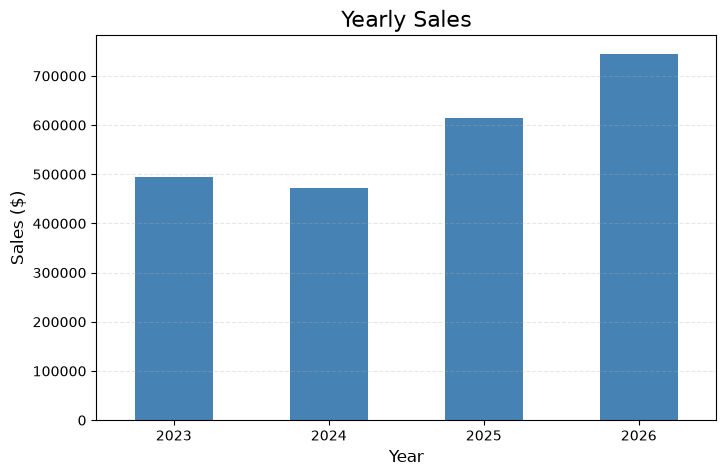

In [16]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Yearly Sales",fontsize=16)

plt.xlabel("Year",fontsize=12)

plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [17]:
yearly_profit = (
    df.groupby("Year")["Profit"]
        .sum()
        .sort_index()
)

yearly_profit.to_frame(name="Total Profit")

,Total Profit
Year,
2023,51684.2957
2024,62020.9695
2025,82665.2018
2026,95926.3476


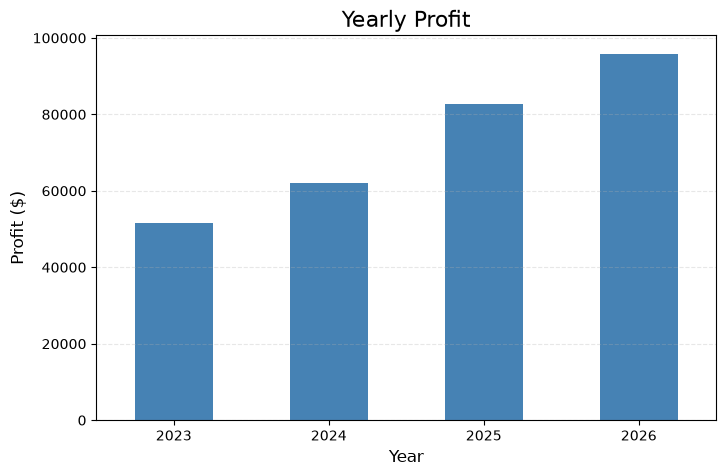

In [18]:
plt.figure(figsize=(8, 5))

yearly_profit.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Yearly Profit",fontsize=16)

plt.xlabel("Year",fontsize=12)

plt.ylabel("Profit ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [19]:
## Business Insight

Yearly sales show a small decline in 2024 compared with 2023, but sales increased significantly in 2025 and reached the highest level in 2026.

Profit increased consistently from 2023 to 2026, indicating that the business has become more profitable over time.

## Recommendation

The business should investigate the reason for the sales decline in 2024 and continue the strategies that contributed to the strong growth in 2025 and 2026.

SyntaxError: invalid syntax (2508283266.py, line 3)

In [19]:
monthly_sales = (
    df.groupby("Month")["Sales"]
        .sum()
        .sort_index()
)

monthly_sales.to_frame(name="Total Sales")

,Total Sales
Month,
1,96069.5156
2,59751.2514
3,210672.0868
4,138098.7486
5,158765.0337
6,153459.9973
7,149001.7130
8,161821.9150
9,308883.6697


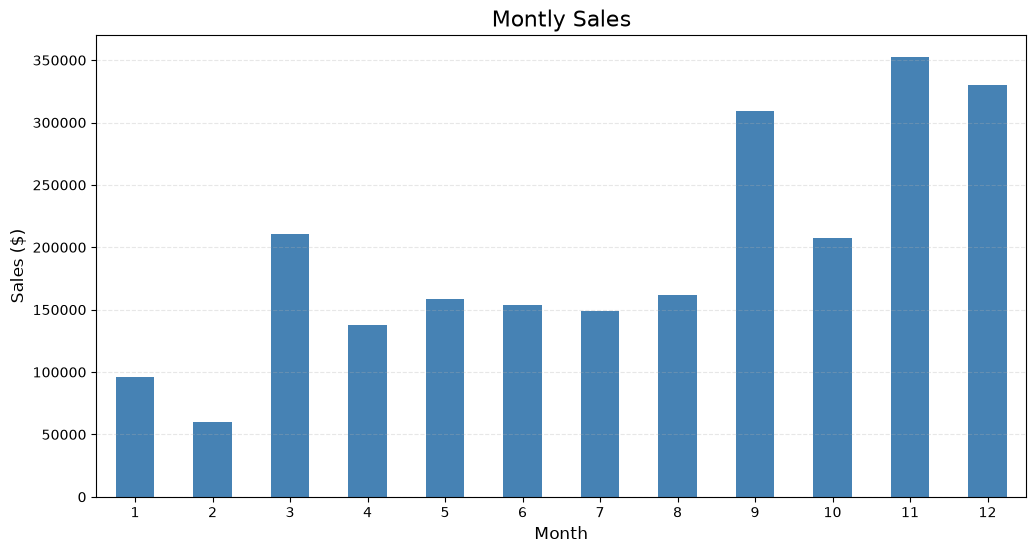

In [20]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Montly Sales", fontsize=16)

plt.xlabel("Month",fontsize=12)

plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

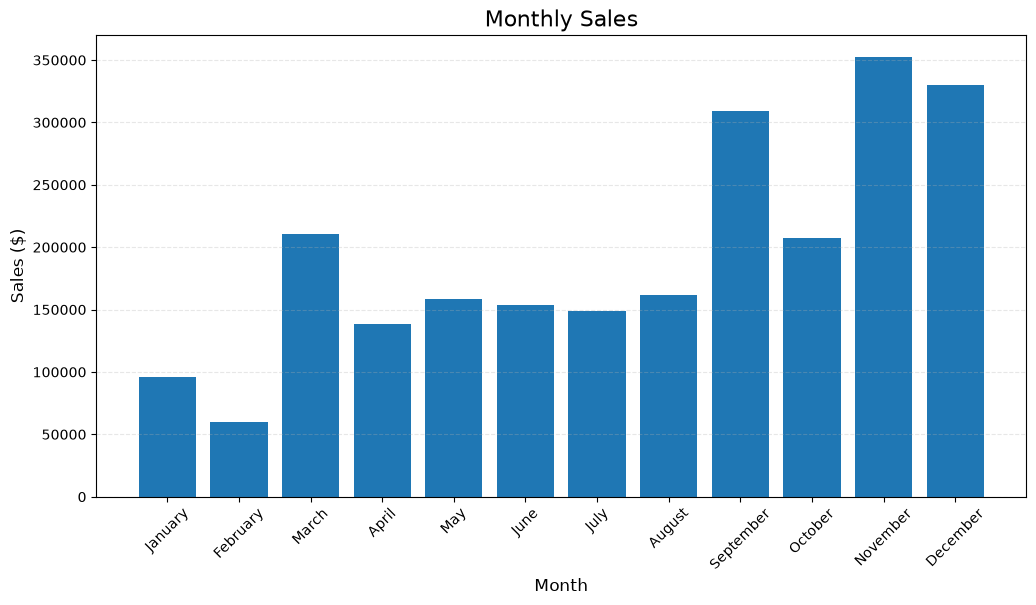

In [21]:
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.figure(figsize=(12, 6))

plt.bar(month_names, monthly_sales.values)

plt.title("Monthly Sales", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [22]:
highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print(f"Highest Sales Month: {highest_sales_month}")
print(f"Highest Sales: ${highest_sales_value:,.2f}")

print(f"Lowest Sales Month: {lowest_sales_month}")
print(f"Lowest Sales: ${lowest_sales_value:,.2f}")

Highest Sales Month: 11
Highest Sales: $352,665.99
Lowest Sales Month: 2
Lowest Sales: $59,751.25


In [23]:
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

print(f"Highest Sales Month: {month_names[highest_sales_month]}")
print(f"Highest Sales: ${highest_sales_value:,.2f}")

print(f"Lowest Sales Month: {month_names[lowest_sales_month]}")
print(f"Lowest Sales: ${lowest_sales_value:,.2f}")

Highest Sales Month: November
Highest Sales: $352,665.99
Lowest Sales Month: February
Lowest Sales: $59,751.25


In [ ]:
## Business Insight

Sales vary significantly across different months.

November generates the highest sales with approximately $352,666, followed by December and September.

February generates the lowest sales with approximately $59,751.

Sales are generally stronger during the September to December period, indicating a possible seasonal increase in customer demand toward the end of the year.

## Recommendation

The business should prepare sufficient inventory and marketing resources before the high-sales period.

Promotional campaigns can be increased during September to December to take advantage of higher customer demand.

During low-sales months such as February, the business can use targeted promotions and discounts to improve sales.

In [24]:
monthly_profit = (
    df.groupby("Month")["Profit"]
        .sum()
        .sort_index()
)

monthly_profit.to_frame(name="Total Profit")

,Total Profit
Month,
1,9497.2501
2,10294.6107
3,29345.0405
4,11625.5223
5,22850.0324
6,21508.2067
7,14013.5496
8,22942.4239
9,37234.5608


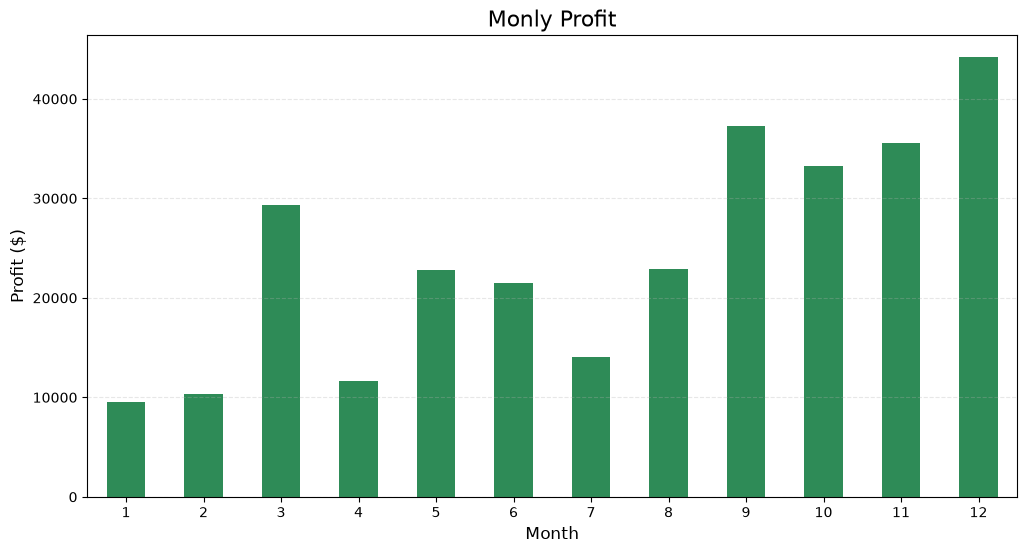

In [25]:
plt.figure(figsize=(12, 6))

monthly_profit.plot(
    kind="bar",
    color="seagreen"
)

plt.title("Monly Profit", fontsize=16)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Profit ($)", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [26]:
highest_profit_month = monthly_profit.idxmax()
highest_profit_value = monthly_profit.max()

lowest_profit_month = monthly_profit.idxmin()
lowest_profit_value = monthly_profit.min()

print(f"Highest Profit Month: {highest_profit_month}")
print(f"HIghest Profit: ${highest_profit_value:,.2f}")

print(f"Lowest Prfoit Month: {lowest_profit_month}")
print(f"Lowest Profit: ${lowest_profit_value:,.2f}")

Highest Profit Month: 12
HIghest Profit: $44,229.85
Lowest Prfoit Month: 1
Lowest Profit: $9,497.25


In [27]:
print(f"Highest Profit Month: {month_names[highest_profit_month]}")
print(f"Highest Profit: ${highest_profit_value:,.2f}")

print(f"Lowest Profit Month: {month_names[lowest_profit_month]}")
print(f"Lowest Profit: ${lowest_profit_value:,.2f}")

Highest Profit Month: December
Highest Profit: $44,229.85
Lowest Profit Month: January
Lowest Profit: $9,497.25


In [ ]:
## Business Insight

Profit varies significantly across different months.

December generates the highest profit of approximately $44,230, while January generates the lowest profit of approximately $9,497.

Interestingly, November has the highest sales, but December generates the highest profit. This shows that high sales do not always result in the highest profit.

The business performs particularly well in the September to December period.

## Recommendation

The business should prepare sufficient inventory and marketing resources before the high-performing months.

Management should also analyze pricing, discounts and product mix during November to understand why sales are highest but profit is lower than December.

Low-profit months such as January should be analyzed to identify opportunities for improving margins and sales.

In [28]:
monthly_profit_margin = (
    monthly_profit / monthly_sales * 100
)

monthly_profit_margin.to_frame(name="Profit Margin (%)")

,Profit Margin (%)
Month,
1,9.885810
2,17.229113
3,13.929249
4,8.418268
5,14.392358
6,14.015514
7,9.404959
8,14.177575
9,12.054558


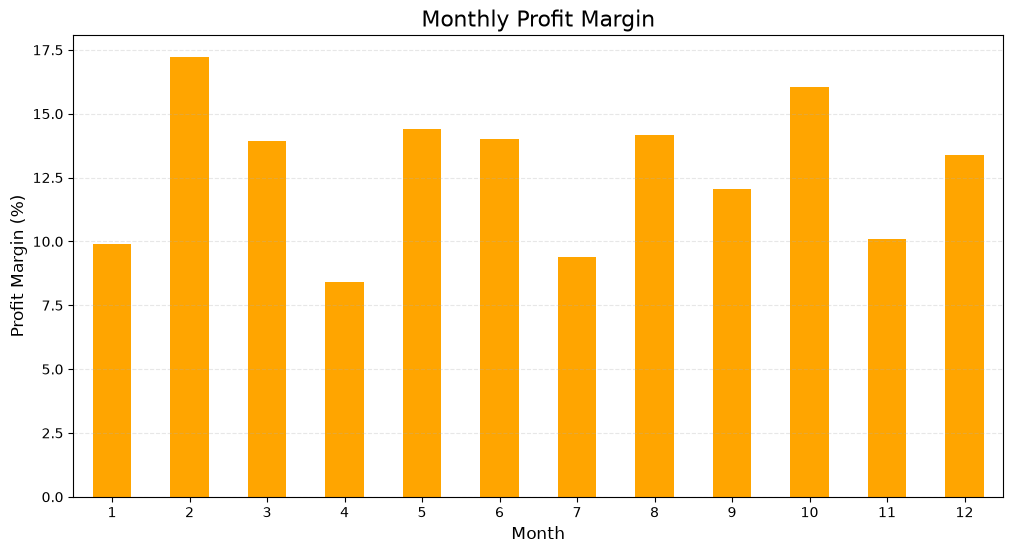

In [29]:
plt.figure(figsize=(12, 6))

monthly_profit_margin.plot(
    kind="bar",
    color="orange"
)

plt.title("Monthly Profit Margin", fontsize=16)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Profit Margin (%)", fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [30]:
## Business Insight

Monthly profit margins vary considerably throughout the year.

February has the highest profit margin at approximately 17.23%, despite having the lowest sales.

April has the lowest profit margin at approximately 8.42%.

November generates the highest sales, but its profit margin is only around 10.08%. This shows that high sales do not necessarily result in high profitability.

October also performs strongly, with a profit margin of approximately 16.04%.

## Recommendation

The business should investigate the factors contributing to the high profit margins in February and October, such as product mix, pricing and discount levels.

The lower margins in April and November should also be investigated to identify whether high discounts, product costs or low-margin products are reducing profitability.

Management should focus on both sales growth and profit margin rather than sales alone.

SyntaxError: invalid syntax (169270340.py, line 3)

In [30]:
quarterly_sales = (
    df.groupby("Quarter")["Sales"]
        .sum()
        .sort_index()
)

quarterly_sales.to_frame(name="Total Sales")

,Total Sales
Quarter,
1,366492.8538
2,450323.7796
3,619707.2977
4,890010.4232


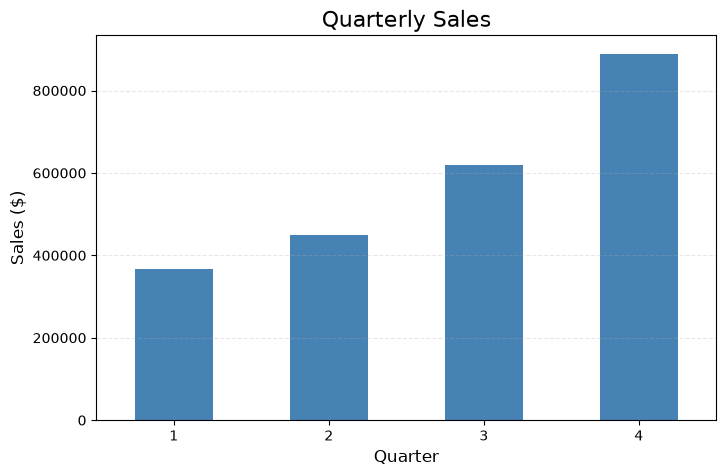

In [31]:
plt.figure(figsize=(8, 5))

quarterly_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Quarterly Sales",fontsize=16)

plt.xlabel("Quarter",fontsize=12)

plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [32]:
quarterly_profit = (
    df.groupby("Quarter")["Profit"]
        .sum()
        .sort_index()
)

quarterly_profit.to_frame(name="Total Profit")

,Total Profit
Quarter,
1,49136.9013
2,55983.7614
3,74190.5343
4,112985.6176


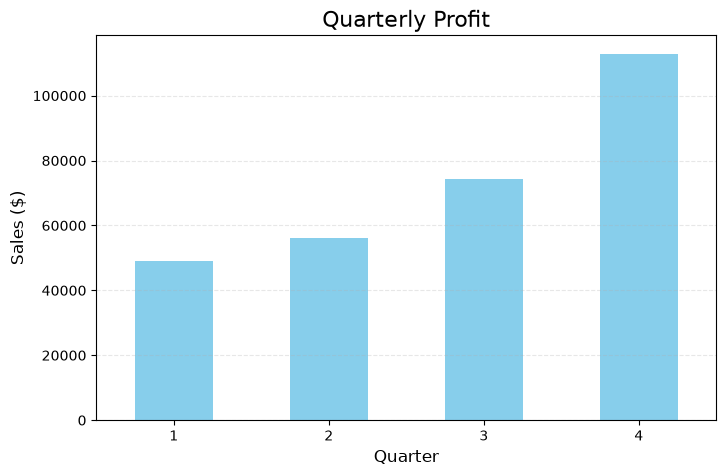

In [33]:
plt.figure(figsize=(8, 5))

quarterly_profit.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Quarterly Profit",fontsize=16)

plt.xlabel("Quarter",fontsize=12)

plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [34]:
quarterly_profit_margin = (
    quarterly_profit / quarterly_sales * 100
)

quarterly_profit_margin.to_frame(name="Profit Margin (%)")

,Profit Margin (%)
Quarter,
1,13.407329
2,12.431891
3,11.971867
4,12.694865


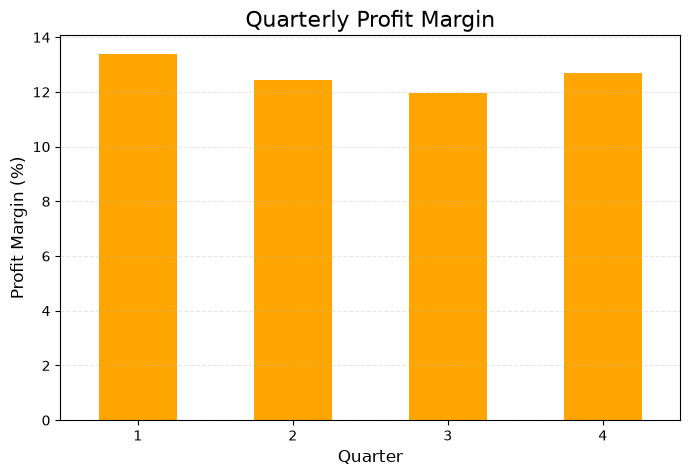

In [35]:
plt.figure(figsize=(8, 5))

quarterly_profit_margin.plot(
    kind="bar",
    color="orange"
)

plt.title("Quarterly Profit Margin",fontsize=16)

plt.xlabel("Quarter",fontsize=12)

plt.ylabel("Profit Margin (%)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [37]:
## Business Insight

Quarterly analysis shows a strong increase in sales and profit throughout the year.

Q4 generates the highest sales of approximately $890,010 and the highest profit of approximately $112,986.

Q1 has the highest profit margin at approximately 13.41%, while Q3 has the lowest profit margin at approximately 11.97%.

Although Q4 generates the highest revenue and profit, Q1 is more efficient in terms of profit margin.

The business appears to experience strong demand toward the end of the year, making Q4 the most important quarter for overall revenue and profit generation.

## Recommendation

The company should prepare sufficient inventory and resources before Q4 to take advantage of the increased demand.

Management should also investigate why Q1 has a higher profit margin and why Q3 has the lowest margin.

Strategies that improve Q3 profitability could help increase overall annual profit.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3933610694.py, line 5)

In [36]:
year_quarter_sales = (
    df.groupby(["Year", "Quarter"])["Sales"]
        .sum()
)

year_quarter_sales.to_frame(name="Total Sales")

Total Sales
Year Quarter             
2023 1         75971.8560
     2         89284.5916
     3        145535.1603
     4        183248.6042
2024 1         70391.9546
     2         89239.4470
     3        130449.3752
     4        182912.2542
2025 1         94840.2150
     2        136809.1450
     3        145538.9762
     4        236745.2438
2026 1        125288.8282
     2        134990.5960
     3        198183.7860
     4        287104.3210

In [37]:
year_quarter_profit = (
    df.groupby(["Year", "Quarter"])["Profit"]
        .sum()
)

year_quarter_profit.to_frame(name="Total Profit")

Total Profit
Year Quarter              
2023 1           4095.1490
     2          11684.9864
     3          13517.3726
     4          22386.7877
2024 1           9554.6612
     2          12200.1904
     3          16880.3008
     4          23385.8171
2025 1          11628.4890
     2          16594.6767
     3          16247.4851
     4          38194.5510
2026 1          23858.6021
     2          15503.9079
     3          27545.3758
     4          29018.4618

In [38]:
year_quarter_margin = (
    year_quarter_profit / year_quarter_sales * 100
)

year_quarter_margin.to_frame(name="Profit Margin (%)")

Profit Margin (%)
Year Quarter                   
2023 1                 5.390350
     2                13.087349
     3                 9.288046
     4                12.216621
2024 1                13.573513
     2                13.671298
     3                12.940116
     4                12.785265
2025 1                12.261137
     2                12.129801
     3                11.163666
     4                16.133186
2026 1                19.042881
     2                11.485176
     3                13.898905
     4                10.107288

In [39]:
quarter_sales_pivot = (
    df.pivot_table(
        index="Year",
        columns="Quarter",
        values="Sales",
        aggfunc="sum"
    )
)

quarter_sales_pivot

Quarter,1,2,3,4
Year,,,,
2023,75971.8560,89284.5916,145535.1603,183248.6042
2024,70391.9546,89239.4470,130449.3752,182912.2542
2025,94840.2150,136809.1450,145538.9762,236745.2438
2026,125288.8282,134990.5960,198183.7860,287104.3210


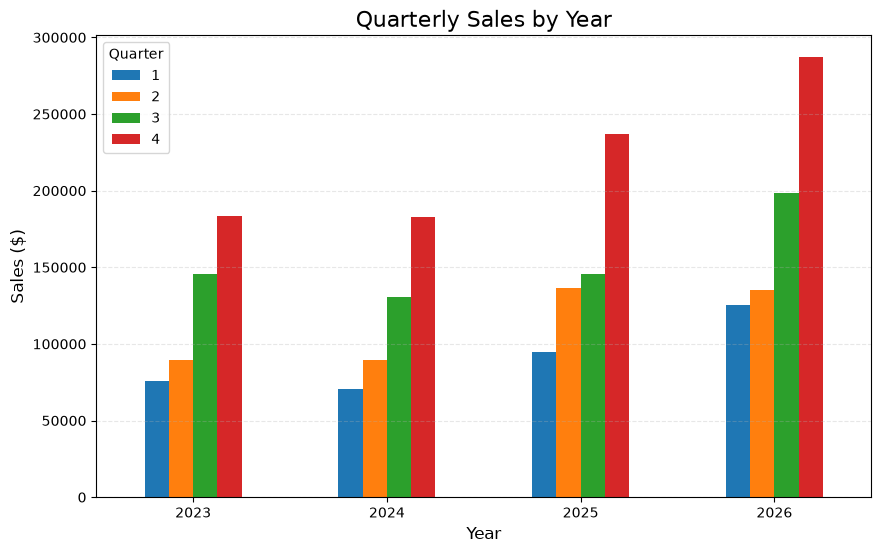

In [40]:
quarter_sales_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Quarterly Sales by Year", fontsize=16)

plt.xlabel("Year",fontsize=12)

plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [47]:
## Business Insights

The Year × Quarter analysis shows a strong seasonal pattern in the business.

Q4 generates the highest sales in every year, indicating that customer demand is consistently stronger during the final quarter.

Q4 sales increased from approximately $183K in 2023 to $287K in 2026, showing strong long-term growth.

However, higher sales do not always result in higher profit margins. In 2026, Q1 achieved the highest profit margin of approximately 19.04%, while Q4 had a much lower margin of approximately 10.11%.

This indicates that although Q4 generates the highest revenue, factors such as discounts, product mix, or other costs may reduce profitability.

## Recommendation

The company should prepare sufficient inventory and resources before Q4 to handle the seasonal increase in demand.

Management should also investigate why Q4 profit margins are lower despite having the highest sales.

The company can study discounts, product categories, shipping costs, and other expenses to identify opportunities to improve Q4 profitability.

SyntaxError: invalid character '×' (U+00D7) (2197301883.py, line 3)

In [41]:
monthly_year_sales = (
    df.groupby(["Year", "Month"])["Sales"]
        .sum()
)

monthly_year_sales.to_frame(name="Total Sales")

Total Sales
Year Month             
2023 1       14518.0550
     2        4519.8920
     3       56933.9090
     4       28295.3450
     5       26319.7670
     6       34669.4796
     7       33946.3930
     8       28918.3385
     9       82670.4288
     10      32413.3390
     11      78826.9567
     12      72008.3085
2024 1       18461.9156
     2       11951.4110
     3       39978.6280
     4       34195.2085
     5       30246.9465
     6       24797.2920
     7       28765.3250
     8       37057.0042
     9       64627.0460
     10      31407.1335
     11      75972.5635
     12      75532.5572
2025 1       18830.3310
     2       22978.8150
     3       53031.0690
     4       38829.1590
     5       57042.8380
     6       40937.1480
     7       40300.4990
     8       31716.8143
     9       73521.6629
     10      59831.0010
     11      79411.9658
     12      97502.2770
2026 1       44259.2140
     2       20301.1334
     3       60728.4808
     4       36779.0361
     5       45155.4822
     6       53056.0777
     7       45989.4960
     8       64129.7580
     9       88064.5320
     10      83474.7832
     11     118454.5050
     12      85175.0328

In [42]:
monthly_year_profit = (
    df.groupby(["Year", "Month"])["Profit"]
        .sum()
)

monthly_year_profit.to_frame(name="Total Profit")

Total Profit
Year Month              
2023 1         2539.3907
     2          862.3084
     3          693.4499
     4         3488.8352
     5         3196.3918
     6         4999.7594
     7         -841.4826
     8         5765.2250
     9         8593.6302
     10        3469.1749
     11        9362.9557
     12        9554.6571
2024 1        -3189.8030
     2         2813.8508
     3         9930.6134
     4         4187.4962
     5         4677.1370
     6         3335.5572
     7         3288.6483
     8         5371.6274
     9         8220.0251
     10        2817.9660
     11       12474.7884
     12        8093.0627
2025 1         2916.0233
     2         5004.5795
     3         3707.8862
     4         2991.6609
     5         8676.6964
     6         4926.3194
     7         4559.8827
     8         2317.4993
     9         9370.1031
     10       16256.8422
     11        4011.4075
     12       17926.3013
2026 1         7231.6391
     2         1613.8720
     3        15013.0910
     4          957.5300
     5         6299.8072
     6         8246.5707
     7         7006.5012
     8         9488.0722
     9        11050.8024
     10       10670.5312
     11        9692.1037
     12        8655.8269

In [43]:
monthly_year_margin = (
    monthly_year_profit / monthly_year_sales * 100
)

monthly_year_margin.to_frame(name="Profit Margin (%)")

Profit Margin (%)
Year Month                   
2023 1              17.491260
     2              19.078075
     3               1.217991
     4              12.330068
     5              12.144453
     6              14.421213
     7              -2.478857
     8              19.936225
     9              10.395047
     10             10.702924
     11             11.877860
     12             13.268826
2024 1             -17.277747
     2              23.544089
     3              24.839805
     4              12.245857
     5              15.463171
     6              13.451296
     7              11.432683
     8              14.495579
     9              12.719172
     10              8.972376
     11             16.420123
     12             10.714668
2025 1              15.485778
     2              21.779102
     3               6.991913
     4               7.704676
     5              15.210843
     6              12.033861
     7              11.314705
     8               7.306848
     9              12.744683
     10             27.171269
     11              5.051389
     12             18.385521
2026 1              16.339285
     2               7.949665
     3              24.721664
     4               2.603467
     5              13.951367
     6              15.543122
     7              15.235003
     8              14.795116
     9              12.548528
     10             12.782940
     11              8.182132
     12             10.162399

In [44]:
monthly_sales_pivot = (
    df.pivot_table(
        index="Month",
        columns="Year",
        values="Sales",
        aggfunc="sum"
    )
)

monthly_sales_pivot

Year,2023,2024,2025,2026
Month,,,,
1,14518.0550,18461.9156,18830.3310,44259.2140
2,4519.8920,11951.4110,22978.8150,20301.1334
3,56933.9090,39978.6280,53031.0690,60728.4808
4,28295.3450,34195.2085,38829.1590,36779.0361
5,26319.7670,30246.9465,57042.8380,45155.4822
6,34669.4796,24797.2920,40937.1480,53056.0777
7,33946.3930,28765.3250,40300.4990,45989.4960
8,28918.3385,37057.0042,31716.8143,64129.7580
9,82670.4288,64627.0460,73521.6629,88064.5320


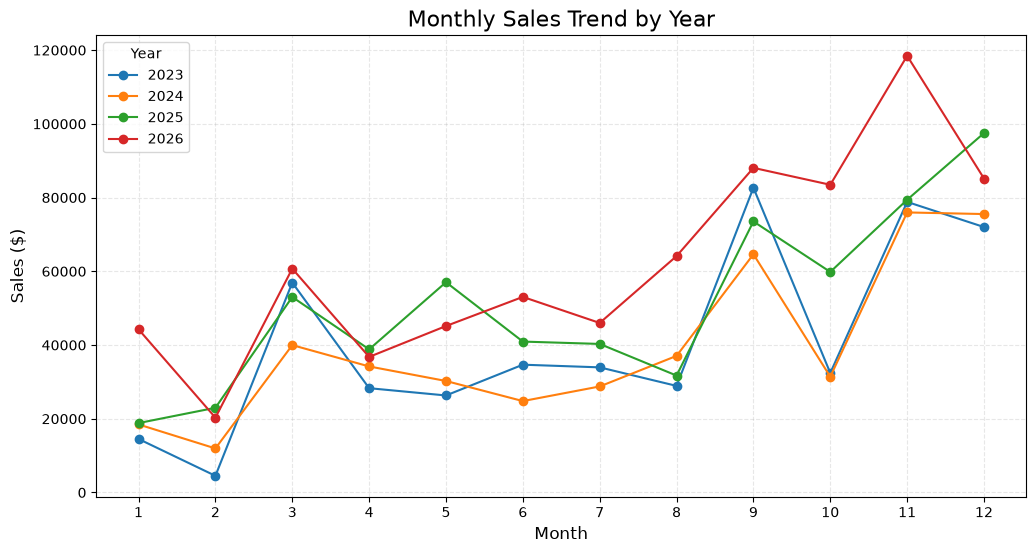

In [45]:
monthly_sales_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Sales Trend by Year",fontsize=16)
plt.xlabel("Month",fontsize=12)
plt.ylabel("Sales ($)",fontsize=12)

plt.xticks(range(1, 13))

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [53]:
## Business Insights

Monthly analysis reveals both a long-term growth trend and strong seasonal patterns.

November consistently generates high sales and reached the highest monthly sales in the dataset in 2026, at approximately $118,455.

September and December are also generally strong-performing months, while February consistently records relatively low sales.

The analysis also shows that high sales do not always result in high profitability. For example, July 2023 generated approximately $33,946 in sales but resulted in a loss of approximately $841.

January 2024 also generated sales of approximately $18,462 but resulted in a loss of approximately $3,190.

The highest monthly profit margin was observed in October 2025 at approximately 27.17%.

These results indicate that the business has both a growth trend and seasonal fluctuations, while profitability is influenced by factors beyond sales volume.

## Recommendation

The company should prepare additional inventory and resources before high-demand periods such as September, November, and December.

Management should investigate months with negative or low profit margins to identify the causes of losses.

Factors such as discounts, product mix, shipping costs, and operating costs should be analyzed to improve profitability.

The company should focus not only on increasing sales but also on maintaining healthy profit margins.

SyntaxError: invalid syntax (867548978.py, line 3)

In [46]:
yearly_sales_growth = yearly_sales.sort_index().pct_change() * 100
yearly_sales_growth.to_frame(name="Sales Growth (%)")

,Sales Growth (%)
Year,
2023,NaN
2024,-4.260216
2025,29.797595
2026,21.441074


In [47]:
yearly_profit_growth = yearly_profit.sort_index().pct_change() * 100
yearly_profit_growth.to_frame(name="Profit Growth (%)")

,Profit Growth (%)
Year,
2023,NaN
2024,19.999641
2025,33.285891
2026,16.041993


In [48]:
## Year-over-Year Growth Insights

Sales declined by approximately 4.26% in 2024 compared with 2023.

However, despite the decline in sales, profit increased by approximately 20%, indicating improved profitability during 2024.

In 2025, the business experienced strong recovery, with sales increasing by approximately 29.80% and profit increasing by approximately 33.29%.

In 2026, sales continued to grow by approximately 21.44%, while profit increased by approximately 16.04%.

Although the business continues to grow, the slower profit growth in 2026 compared with sales growth should be investigated.

## Recommendation

Management should investigate the factors affecting profit growth, including discounts, product mix, pricing, and costs.

The company should focus on maintaining both revenue growth and healthy profit margins rather than focusing only on increasing sales.

SyntaxError: invalid syntax (2607241139.py, line 3)

In [49]:
monthly_sales_sorted = (
    df.groupby("Month")["Sales"]
        .sum()
        .sort_index()
)

monthly_sales_ma3 = (
    monthly_sales_sorted
            .rolling(window=3)
            .mean()
)

monthly_sales_ma3.to_frame(name="3-Month Moving Average")

,3-Month Moving Average
Month,
1,NaN
2,NaN
3,122164.284600
4,136174.028933
5,169178.623033
6,150107.926533
7,153742.248000
8,154761.208433
9,206569.099233


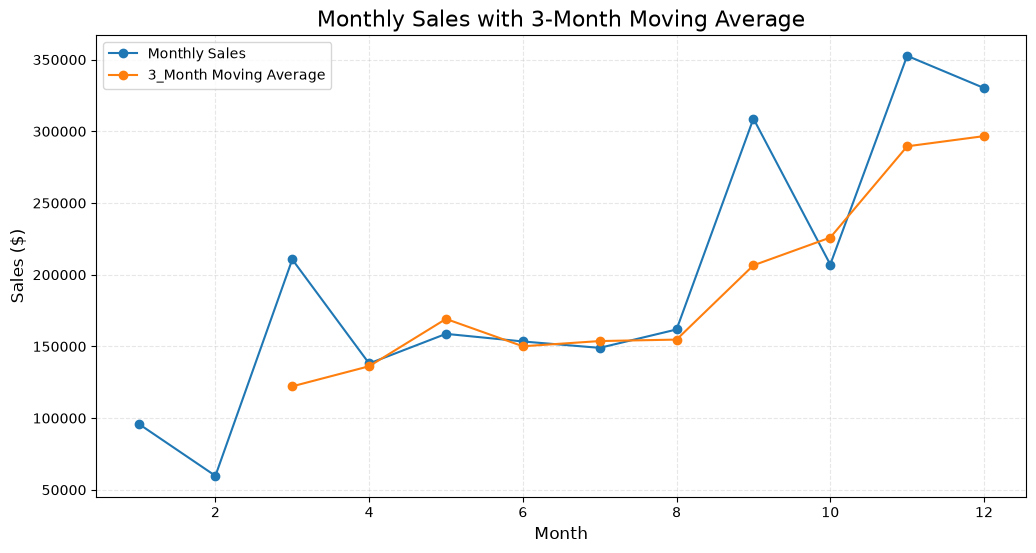

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_sorted.index,
    monthly_sales_sorted.values,
    marker="o",
    label="Monthly Sales"
)

plt.plot(
    monthly_sales_ma3.index,
    monthly_sales_ma3.values,
    marker="o",
    label="3_Month Moving Average"
)

plt.title("Monthly Sales with 3-Month Moving Average", fontsize=16)
plt.xlabel("Month",fontsize=12)
plt.ylabel("Sales ($)",fontsize=12)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [51]:
monthly_sales_ts = (
    df.set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
)

monthly_sales_ts.to_frame(name="Total Sales").head(10)

,Total Sales
Order Date,
2023-01-01,14518.0550
2023-02-01,4519.8920
2023-03-01,56933.9090
2023-04-01,28295.3450
2023-05-01,26319.7670
2023-06-01,34669.4796
2023-07-01,33946.3930
2023-08-01,28918.3385
2023-09-01,82670.4288


In [52]:
print("Start: ",monthly_sales_ts.index.min())
print("End: ",monthly_sales_ts.index.max())
print("Number of Months: ",len(monthly_sales_ts))

Start:  2023-01-01 00:00:00
End:  2026-12-01 00:00:00
Number of Months:  48


In [53]:
monthly_ma3 = (
    monthly_sales_ts
    .rolling(window=3)
    .mean()
)

monthly_ma3.to_frame(name="3-Month Moving Average").head(10)

,3-Month Moving Average
Order Date,
2023-01-01,NaN
2023-02-01,NaN
2023-03-01,25323.952000
2023-04-01,29916.382000
2023-05-01,37183.007000
2023-06-01,29761.530533
2023-07-01,31645.213200
2023-08-01,32511.403700
2023-09-01,48511.720100


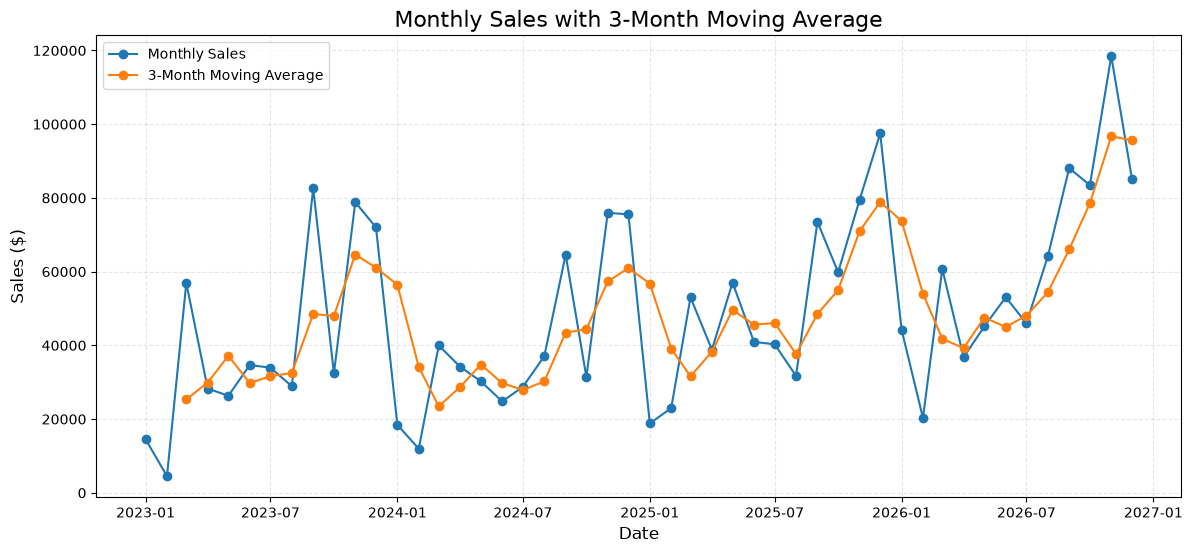

In [54]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts.values,
    marker="o",
    label="Monthly Sales"
)

plt.plot(
    monthly_ma3.index,
    monthly_ma3.values,
    marker="o",
    label="3-Month Moving Average"
)

plt.title("Monthly Sales with 3-Month Moving Average", fontsize=16)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [55]:
monthly_ma6 = monthly_sales_ts.rolling(window=6).mean()
monthly_ma6.to_frame(name="6-Month Moving Average").head(10)

,6-Month Moving Average
Order Date,
2023-01-01,NaN
2023-02-01,NaN
2023-03-01,NaN
2023-04-01,NaN
2023-05-01,NaN
2023-06-01,27542.741267
2023-07-01,30780.797600
2023-08-01,34847.205350
2023-09-01,39136.625317


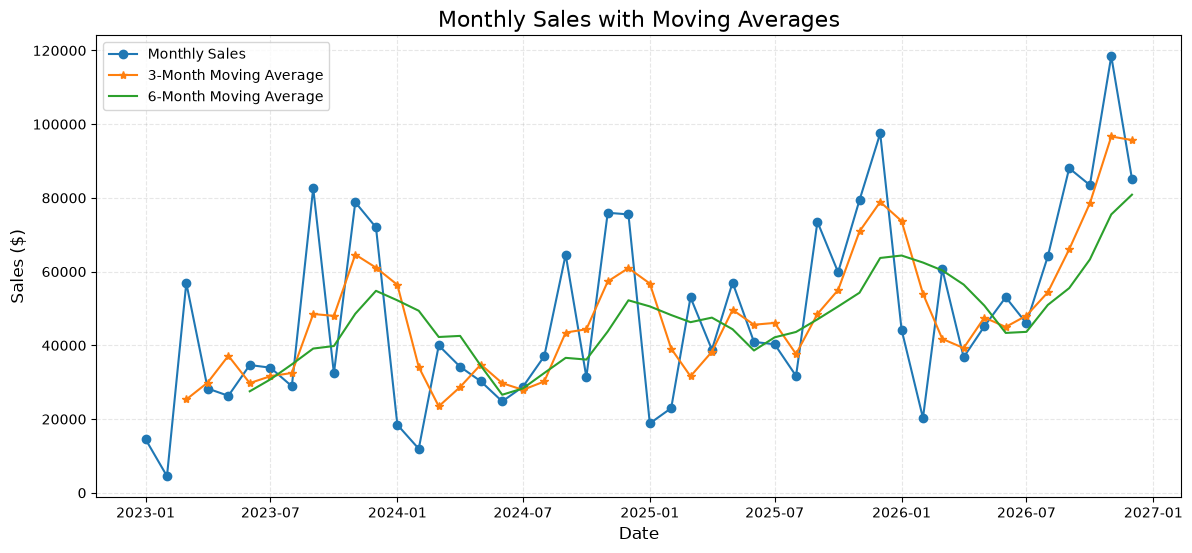

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts.values,
    marker="o",
    label="Monthly Sales"
)

plt.plot(
    monthly_ma3.index,
    monthly_ma3.values,
    marker="*",
    label="3-Month Moving Average"
)

plt.plot(
    monthly_ma6.index,
    monthly_ma6.values,
    label="6-Month Moving Average"
)

plt.title("Monthly Sales with Moving Averages",fontsize=16)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Sales ($)",fontsize=12)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

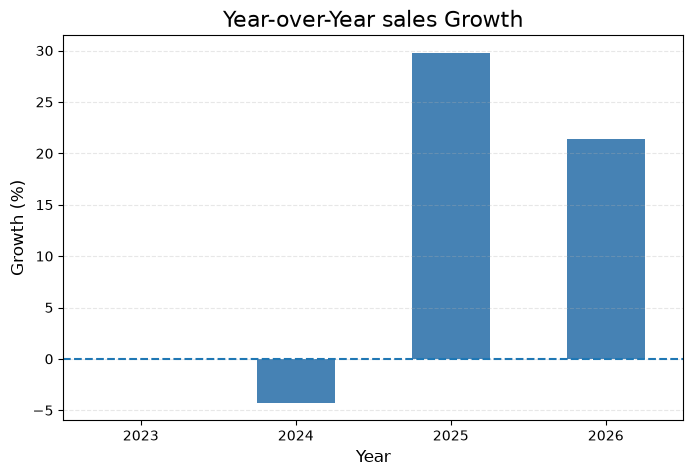

In [57]:
plt.figure(figsize=(8, 5))

yearly_sales_growth.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Year-over-Year sales Growth",fontsize=16)
plt.xlabel("Year",fontsize=12)
plt.ylabel("Growth (%)",fontsize=12)

plt.xticks(rotation=0)
plt.axhline(0, linestyle="--")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [58]:
monthly_sales_by_year = (
    df.groupby(["Year", "Month"])["Sales"]
        .sum()
        .unstack()
)

monthly_sales_by_year

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2023,14518.0550,4519.8920,56933.9090,28295.3450,26319.7670,34669.4796,33946.393,28918.3385,82670.4288,32413.3390,78826.9567,72008.3085
2024,18461.9156,11951.4110,39978.6280,34195.2085,30246.9465,24797.2920,28765.325,37057.0042,64627.0460,31407.1335,75972.5635,75532.5572
2025,18830.3310,22978.8150,53031.0690,38829.1590,57042.8380,40937.1480,40300.499,31716.8143,73521.6629,59831.0010,79411.9658,97502.2770
2026,44259.2140,20301.1334,60728.4808,36779.0361,45155.4822,53056.0777,45989.496,64129.7580,88064.5320,83474.7832,118454.5050,85175.0328


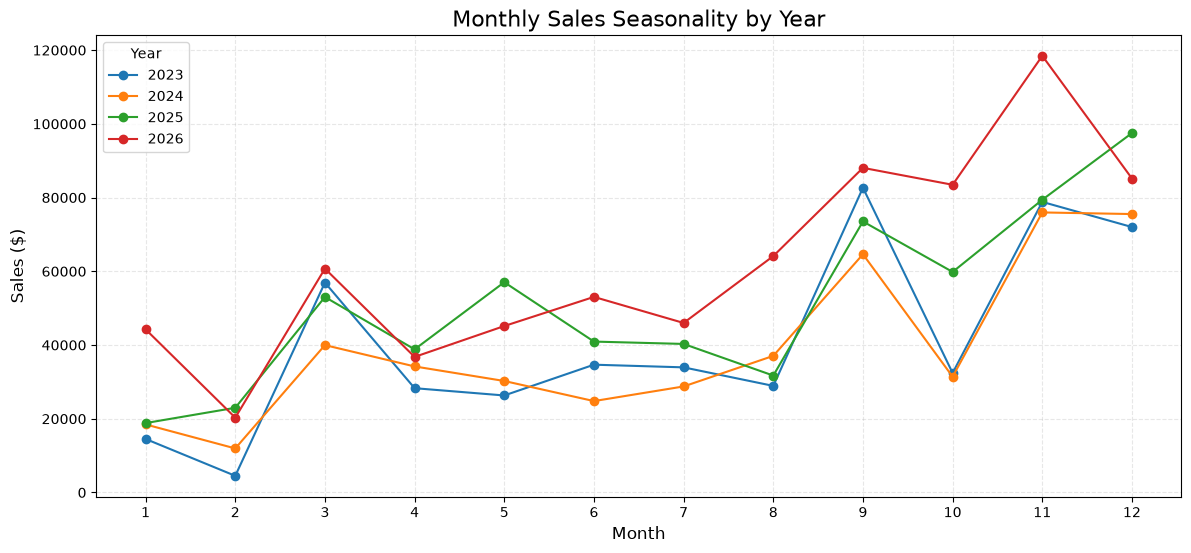

In [59]:
plt.figure(figsize=(14, 6))

for year in monthly_sales_by_year.index:
    plt.plot(
        monthly_sales_by_year.columns,
        monthly_sales_by_year.loc[year],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Sales Seasonality by Year", fontsize=16)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales ($)", fontsize=12)

plt.xticks(range(1, 13))

plt.legend(title="Year")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [68]:
Seasonality Analysis: Sales show a recurring seasonal pattern, with February generally 
recording lower sales and September, November, and December showing stronger sales.
The seasonal peaks become more pronounced in the later years, particularly in 2026. 
This indicates the presence of both seasonality and an overall upward trend in sales.

SyntaxError: invalid syntax (1414384240.py, line 1)

In [60]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [61]:
df["Order Date"].dtype

dtype('<M8[us]')

In [62]:
df_time = df.set_index("Order Date")
df_time.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter
Order Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,1,US-2023-103800,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,1
2023-01-04,2,US-2023-112326,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,1
2023-01-04,3,US-2023-112326,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January,1
2023-01-04,4,US-2023-112326,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,1
2023-01-05,5,US-2023-141817,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,1


In [63]:
df_time.index

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-04', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-06', '2023-01-06',
               '2023-01-06', '2023-01-06',
               ...
               '2026-12-29', '2026-12-29', '2026-12-30', '2026-12-30',
               '2026-12-30', '2026-12-30', '2026-12-30', '2026-12-30',
               '2026-12-30', '2026-12-30'],
              dtype='datetime64[us]', name='Order Date', length=10194, freq=None)

In [64]:
monthly_sales_resample = (
    df_time["Sales"]
    .resample("ME")
    .sum()
)

monthly_sales_resample.to_frame(name="Monthly Sales")

,Monthly Sales
Order Date,
2023-01-31,14518.0550
2023-02-28,4519.8920
2023-03-31,56933.9090
2023-04-30,28295.3450
2023-05-31,26319.7670
2023-06-30,34669.4796
2023-07-31,33946.3930
2023-08-31,28918.3385
2023-09-30,82670.4288


In [65]:
monthly_profit_resample = (
    df_time["Profit"]
    .resample("ME")
    .sum()
)

monthly_profit_resample.to_frame(name="Monthly Profit")

,Monthly Profit
Order Date,
2023-01-31,2539.3907
2023-02-28,862.3084
2023-03-31,693.4499
2023-04-30,3488.8352
2023-05-31,3196.3918
2023-06-30,4999.7594
2023-07-31,-841.4826
2023-08-31,5765.2250
2023-09-30,8593.6302


In [66]:
monthly_sales_avg_resample = (
    df_time["Sales"]
    .resample("ME")
    .mean()
)

monthly_sales_avg_resample.to_frame(name="Monthly Average Sales")

,Monthly Average Sales
Order Date,
2023-01-31,172.833988
2023-02-28,98.258522
2023-03-31,358.074899
2023-04-30,209.595148
2023-05-31,199.392174
2023-06-30,254.922644
2023-07-31,237.387364
2023-08-31,183.027459
2023-09-30,302.822084


In [67]:
monthly_orders = (
    df_time["Order ID"]
    .resample("ME")
    .count()
)

monthly_orders.to_frame(name="Monthly Orders")

,Monthly Orders
Order Date,
2023-01-31,84
2023-02-28,46
2023-03-31,159
2023-04-30,135
2023-05-31,132
2023-06-30,136
2023-07-31,143
2023-08-31,158
2023-09-30,273


In [68]:
monthly_summary = (
    df_time[["Sales", "Profit"]]
    .resample("ME")
    .sum()
)

monthly_summary

,Sales,Profit
Order Date,,
2023-01-31,14518.0550,2539.3907
2023-02-28,4519.8920,862.3084
2023-03-31,56933.9090,693.4499
2023-04-30,28295.3450,3488.8352
2023-05-31,26319.7670,3196.3918
2023-06-30,34669.4796,4999.7594
2023-07-31,33946.3930,-841.4826
2023-08-31,28918.3385,5765.2250
2023-09-30,82670.4288,8593.6302


In [69]:
monthly_summary["Profit Margin (%)"] = (
    monthly_summary["Profit"] / monthly_summary["Sales"] * 100
)

monthly_summary

,Sales,Profit,Profit Margin (%)
Order Date,,,
2023-01-31,14518.0550,2539.3907,17.491260
2023-02-28,4519.8920,862.3084,19.078075
2023-03-31,56933.9090,693.4499,1.217991
2023-04-30,28295.3450,3488.8352,12.330068
2023-05-31,26319.7670,3196.3918,12.144453
2023-06-30,34669.4796,4999.7594,14.421213
2023-07-31,33946.3930,-841.4826,-2.478857
2023-08-31,28918.3385,5765.2250,19.936225
2023-09-30,82670.4288,8593.6302,10.395047


In [70]:
quarterly_summary = (
    df_time[["Sales", "Profit"]]
    .resample("QE")
    .sum()
)

quarterly_summary

,Sales,Profit
Order Date,,
2023-03-31,75971.8560,4095.1490
2023-06-30,89284.5916,11684.9864
2023-09-30,145535.1603,13517.3726
2023-12-31,183248.6042,22386.7877
2024-03-31,70391.9546,9554.6612
2024-06-30,89239.4470,12200.1904
2024-09-30,130449.3752,16880.3008
2024-12-31,182912.2542,23385.8171
2025-03-31,94840.2150,11628.4890


In [71]:
yearly_summary = (
    df_time[["Sales", "Profit"]]
    .resample("YE")
    .sum()
)

yearly_summary

,Sales,Profit
Order Date,,
2023-12-31,494040.2121,51684.2957
2024-12-31,472993.0310,62020.9695
2025-12-31,613933.5800,82665.2018
2026-12-31,745567.5312,95926.3476


In [72]:
previous_year_sales = yearly_sales.shift(1)

previous_year_sales.to_frame(name="Previous Year sales")

,Previous Year sales
Year,
2023,NaN
2024,494040.2121
2025,472993.0310
2026,613933.5800


In [73]:
yearly_comparsion = pd.DataFrame({
    "Current Sales": yearly_sales,
    "Previous Year Sales": yearly_sales.shift(1)
})

yearly_comparsion

,Current Sales,Previous Year Sales
Year,,
2023,494040.2121,NaN
2024,472993.0310,494040.2121
2025,613933.5800,472993.0310
2026,745567.5312,613933.5800


In [74]:
yearly_comparsion["Sales Change"] = (
    yearly_comparsion["Current Sales"]
    - yearly_comparsion["Previous Year Sales"]
)

yearly_comparsion

,Current Sales,Previous Year Sales,Sales Change
Year,,,
2023,494040.2121,NaN,NaN
2024,472993.0310,494040.2121,-21047.1811
2025,613933.5800,472993.0310,140940.5490
2026,745567.5312,613933.5800,131633.9512


In [75]:
yearly_comparsion["Sales Growth (%)"] = (
    yearly_comparsion["Sales Change"] / 
    yearly_comparsion["Previous Year Sales"] * 100
)

yearly_comparsion

,Current Sales,Previous Year Sales,Sales Change,Sales Growth (%)
Year,,,,
2023,494040.2121,NaN,NaN,NaN
2024,472993.0310,494040.2121,-21047.1811,-4.260216
2025,613933.5800,472993.0310,140940.5490,29.797595
2026,745567.5312,613933.5800,131633.9512,21.441074


In [76]:
monthly_sales_ts= (
    df_time["Sales"]
    .resample("ME")
    .sum()
)

monthly_sales_ts.to_frame(name="Total Sales")

,Total Sales
Order Date,
2023-01-31,14518.0550
2023-02-28,4519.8920
2023-03-31,56933.9090
2023-04-30,28295.3450
2023-05-31,26319.7670
2023-06-30,34669.4796
2023-07-31,33946.3930
2023-08-31,28918.3385
2023-09-30,82670.4288


In [77]:
monthly_sales_last_year = monthly_sales_ts.shift(12)

In [78]:
monthly_yoy = pd.DataFrame({
    "Current Sales": monthly_sales_ts,
    "Same Month Last Year": monthly_sales_last_year
})

monthly_yoy

,Current Sales,Same Month Last Year
Order Date,,
2023-01-31,14518.0550,NaN
2023-02-28,4519.8920,NaN
2023-03-31,56933.9090,NaN
2023-04-30,28295.3450,NaN
2023-05-31,26319.7670,NaN
2023-06-30,34669.4796,NaN
2023-07-31,33946.3930,NaN
2023-08-31,28918.3385,NaN
2023-09-30,82670.4288,NaN


In [79]:
monthly_yoy["YoY Growth (%)"] = (
    (
        monthly_yoy["Current Sales"]
        - monthly_yoy["Same Month Last Year"]
    )
    / monthly_yoy["Same Month Last Year"]
) * 100

monthly_yoy

,Current Sales,Same Month Last Year,YoY Growth (%)
Order Date,,,
2023-01-31,14518.0550,NaN,NaN
2023-02-28,4519.8920,NaN,NaN
2023-03-31,56933.9090,NaN,NaN
2023-04-30,28295.3450,NaN,NaN
2023-05-31,26319.7670,NaN,NaN
2023-06-30,34669.4796,NaN,NaN
2023-07-31,33946.3930,NaN,NaN
2023-08-31,28918.3385,NaN,NaN
2023-09-30,82670.4288,NaN,NaN


In [80]:
monthly_analysis = pd.DataFrame({
    "Sales": monthly_sales_ts,
    "3-Month Moving Average": monthly_sales_ts.rolling(3).mean(),
    "6-Month Moving Average": monthly_sales_ts.rolling(6).mean()
})

monthly_analysis

,Sales,3-Month Moving Average,6-Month Moving Average
Order Date,,,
2023-01-31,14518.0550,NaN,NaN
2023-02-28,4519.8920,NaN,NaN
2023-03-31,56933.9090,25323.952000,NaN
2023-04-30,28295.3450,29916.382000,NaN
2023-05-31,26319.7670,37183.007000,NaN
2023-06-30,34669.4796,29761.530533,27542.741267
2023-07-31,33946.3930,31645.213200,30780.797600
2023-08-31,28918.3385,32511.403700,34847.205350
2023-09-30,82670.4288,48511.720100,39136.625317


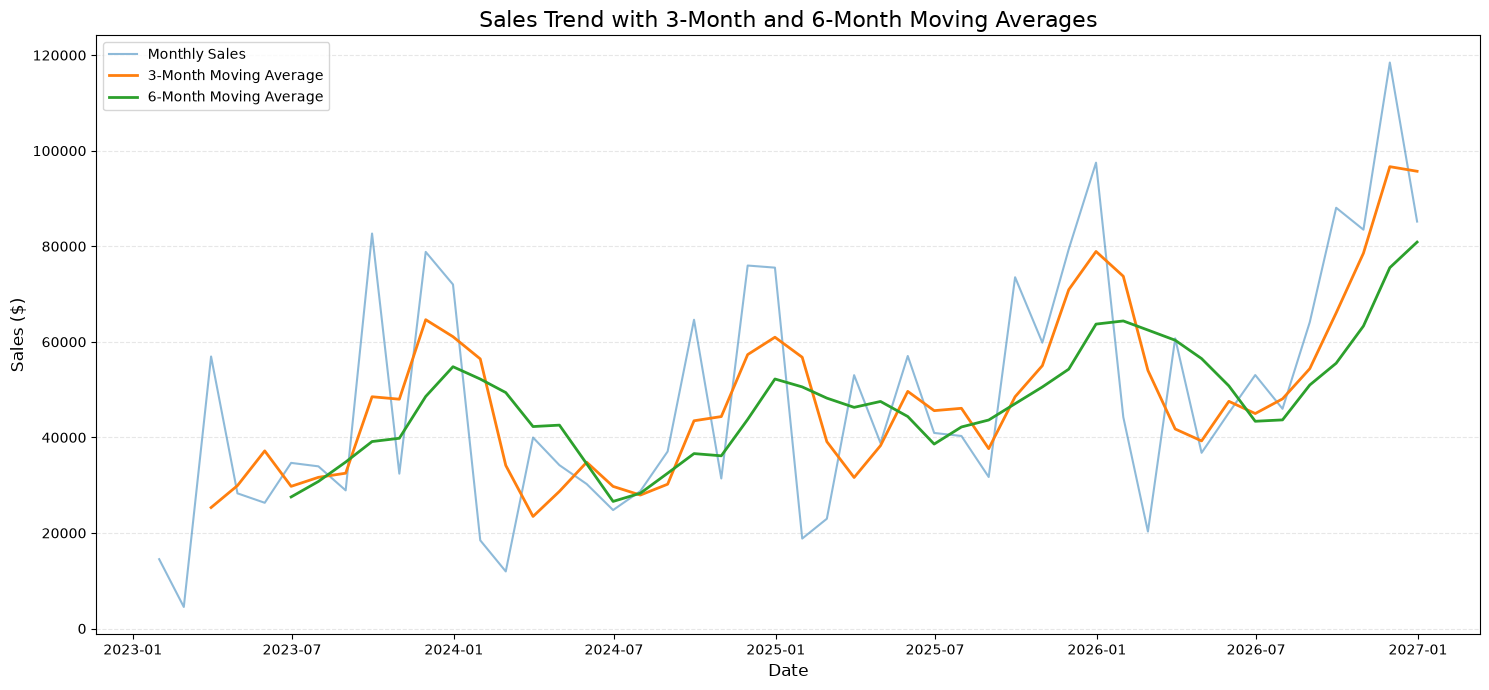

In [81]:
plt.figure(figsize=(15, 7))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["Sales"],
    label="Monthly Sales",
    alpha=0.5
)

plt.plot(
    monthly_analysis.index,
    monthly_analysis["3-Month Moving Average"],
    label="3-Month Moving Average",
    linewidth=2
)

plt.plot(
    monthly_analysis.index,
    monthly_analysis["6-Month Moving Average"],
    label="6-Month Moving Average",
    linewidth=2
)

plt.title("Sales Trend with 3-Month and 6-Month Moving Averages",fontsize=16)

plt.xlabel("Date",fontsize=12)
plt.ylabel("Sales ($)",fontsize=12)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [82]:
cumulative_sales = monthly_sales_ts.cumsum()

cumulative_sales.to_frame(name="Cumulative Sales").head(10)

,Cumulative Sales
Order Date,
2023-01-31,14518.0550
2023-02-28,19037.9470
2023-03-31,75971.8560
2023-04-30,104267.2010
2023-05-31,130586.9680
2023-06-30,165256.4476
2023-07-31,199202.8406
2023-08-31,228121.1791
2023-09-30,310791.6079


In [83]:
monthly_profit_ts = (
    df_time["Profit"]
    .resample("ME")
    .sum()
)

monthly_profit_ts.to_frame(name="Monthly Profit")

,Monthly Profit
Order Date,
2023-01-31,2539.3907
2023-02-28,862.3084
2023-03-31,693.4499
2023-04-30,3488.8352
2023-05-31,3196.3918
2023-06-30,4999.7594
2023-07-31,-841.4826
2023-08-31,5765.2250
2023-09-30,8593.6302


In [84]:
cumulative_profit = monthly_profit_ts.cumsum()

cumulative_profit.to_frame(name="Cumulative Profit").head(10)

,Cumulative Profit
Order Date,
2023-01-31,2539.3907
2023-02-28,3401.6991
2023-03-31,4095.1490
2023-04-30,7583.9842
2023-05-31,10780.3760
2023-06-30,15780.1354
2023-07-31,14938.6528
2023-08-31,20703.8778
2023-09-30,29297.5080


In [85]:
cumulative_analysis = pd.DataFrame({
    "Cumulative Sales": cumulative_sales,
    "Cumulative Profit": cumulative_profit
})

cumulative_analysis

,Cumulative Sales,Cumulative Profit
Order Date,,
2023-01-31,1.451806e+04,2539.3907
2023-02-28,1.903795e+04,3401.6991
2023-03-31,7.597186e+04,4095.1490
2023-04-30,1.042672e+05,7583.9842
2023-05-31,1.305870e+05,10780.3760
2023-06-30,1.652564e+05,15780.1354
2023-07-31,1.992028e+05,14938.6528
2023-08-31,2.281212e+05,20703.8778
2023-09-30,3.107916e+05,29297.5080


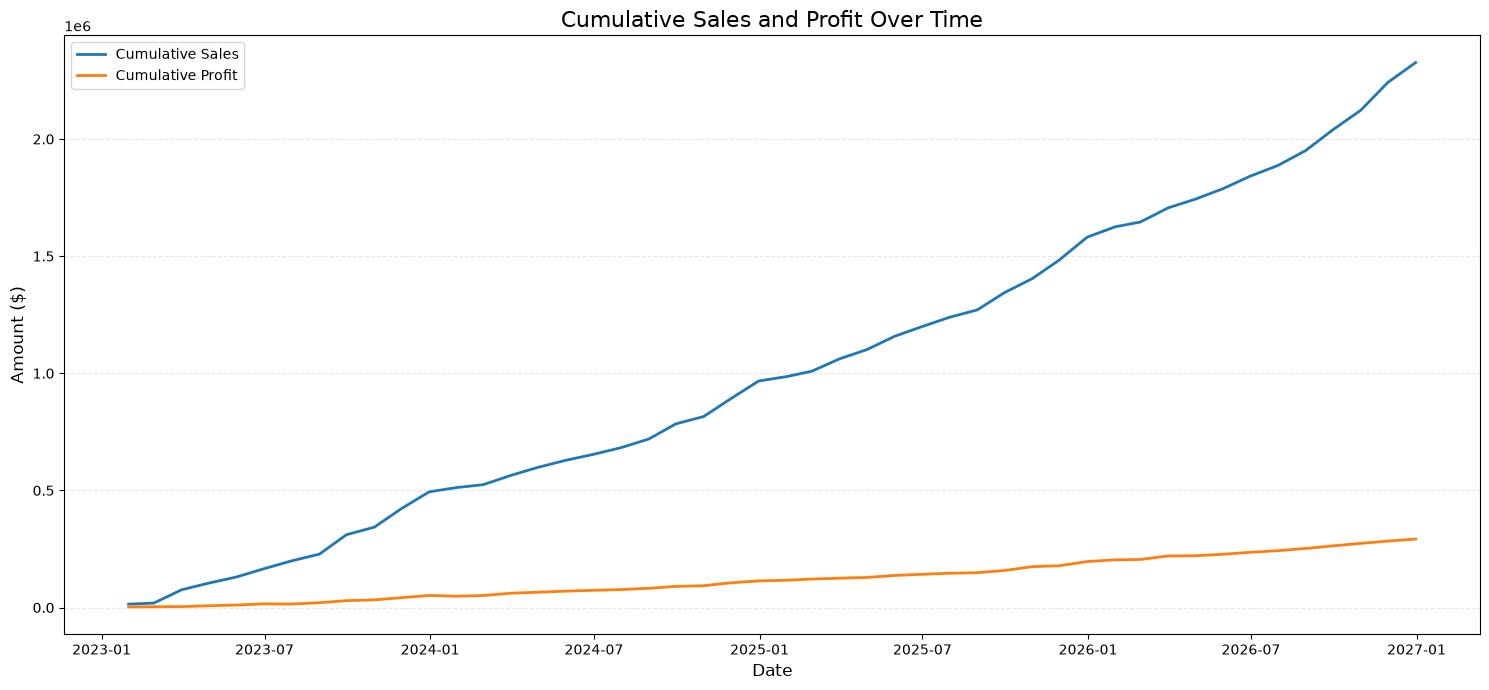

In [86]:
plt.figure(figsize=(15, 7))

plt.plot(
    cumulative_analysis.index,
    cumulative_analysis["Cumulative Sales"],
    label="Cumulative Sales",
    linewidth=2
)

plt.plot(
    cumulative_analysis.index,
    cumulative_analysis["Cumulative Profit"],
    label="Cumulative Profit",
    linewidth=2
)

plt.title("Cumulative Sales and Profit Over Time",fontsize=16)

plt.xlabel("Date",fontsize=12)
plt.ylabel("Amount ($)",fontsize=12)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [109]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.6 MB 7.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 7.1 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 7.3 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.6 MB 7.2 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 7.2 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.6 MB 7.0 MB/s eta 0:00:05
   --- ------------------------------------ 2.9/36.6 MB 7.0 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/36.6 MB 7.1 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/36.6 MB 5.9 MB/s eta 0:00:06
   ------ --------------

In [87]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df = df.set_index("Order Date")
df.index

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-04', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-06', '2023-01-06',
               '2023-01-06', '2023-01-06',
               ...
               '2026-12-29', '2026-12-29', '2026-12-30', '2026-12-30',
               '2026-12-30', '2026-12-30', '2026-12-30', '2026-12-30',
               '2026-12-30', '2026-12-30'],
              dtype='datetime64[us]', name='Order Date', length=10194, freq=None)

In [88]:
monthly_sales = df.resample("ME")["Sales"].sum()

In [89]:
print(len(monthly_sales))

48


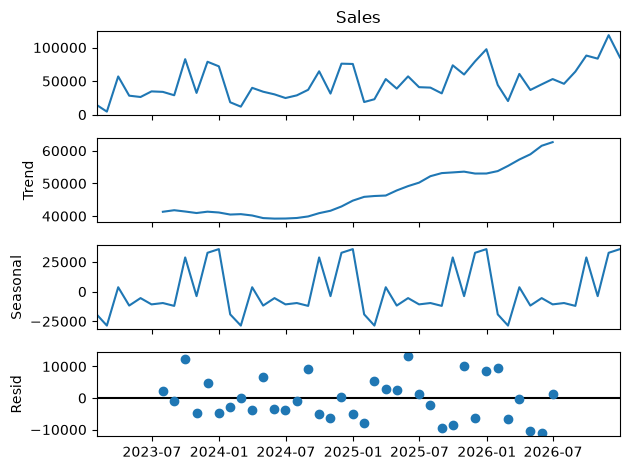

In [90]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()

plt.show()

In [91]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Trend:")
print(trend.head(15))

print("Seasonal:")
print(seasonal.head(15))

print("Residual:")
print(residual.head(15))

Trend:
Order Date
2023-01-31             NaN
2023-02-28             NaN
2023-03-31             NaN
2023-04-30             NaN
2023-05-31             NaN
2023-06-30             NaN
2023-07-31    41334.345200
2023-08-31    41808.319350
2023-09-30    41411.495933
2023-10-31    40950.853537
2023-11-30    41360.313662
2023-12-31    41112.604992
2024-01-31    40485.386008
2024-02-29    40608.619246
2024-03-31    40195.922700
Freq: ME, Name: trend, dtype: float64
Seasonal:
Order Date
2023-01-31   -19136.779110
2023-02-28   -28566.458989
2023-03-31     3705.181552
2023-04-30   -11723.848007
2023-05-31    -5436.129647
2023-06-30   -10720.966433
2023-07-31    -9589.472848
2023-08-31   -11995.081743
2023-09-30    28775.358863
2023-10-31    -3784.393967
2023-11-30    32689.507335
2023-12-31    35783.082995
2024-01-31   -19136.779110
2024-02-29   -28566.458989
2024-03-31     3705.181552
Freq: ME, Name: seasonal, dtype: float64
Residual:
Order Date
2023-01-31             NaN
2023-02-28             N

In [92]:
seasonal_by_month = seasonal.groupby(
    seasonal.index.month
).mean()

print(seasonal_by_month)

Order Date
1    -19136.779110
2    -28566.458989
3      3705.181552
4    -11723.848007
5     -5436.129647
6    -10720.966433
7     -9589.472848
8    -11995.081743
9     28775.358863
10    -3784.393967
11    32689.507335
12    35783.082995
Name: seasonal, dtype: float64


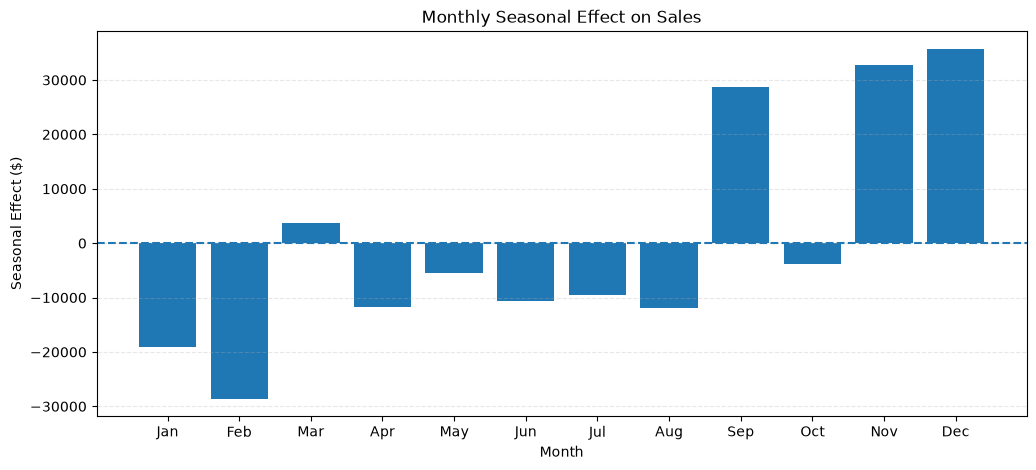

In [93]:
months = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

plt.figure(figsize=(12, 5))

plt.bar(months, seasonal_by_month.values)

plt.axhline(0, linestyle="--")

plt.title("Monthly Seasonal Effect on Sales")
plt.xlabel("Month")
plt.ylabel("Seasonal Effect ($)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [94]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("The series is Stationary")
else:
    print("The series is Non-Stationary")

ADF Statistic: -4.437507341232084
p-value: 0.0002546064925406147
The series is Stationary


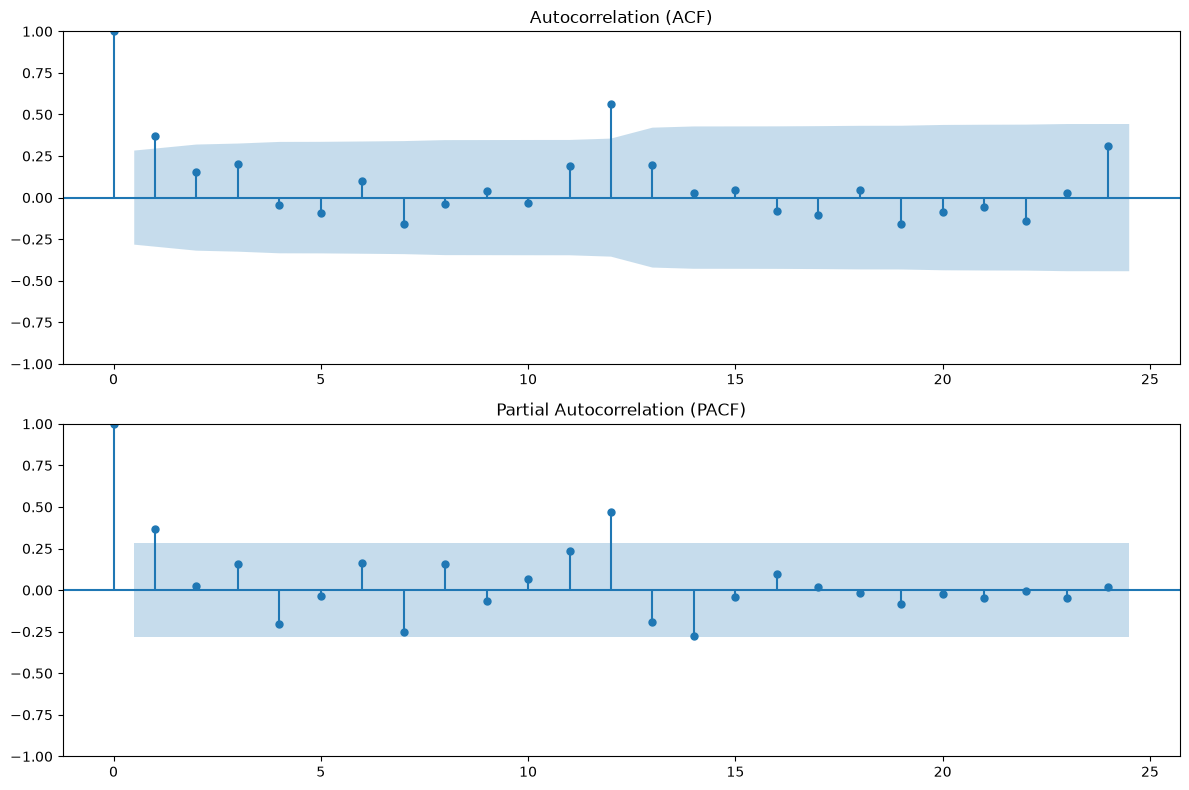

In [95]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(monthly_sales, ax=axes[0], lags=24)
axes[0].set_title("Autocorrelation (ACF)")

plot_pacf(monthly_sales, ax=axes[1], lags=24)
axes[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

In [96]:
top_product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_product_sales.to_frame(name="Total Sales")

,Total Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


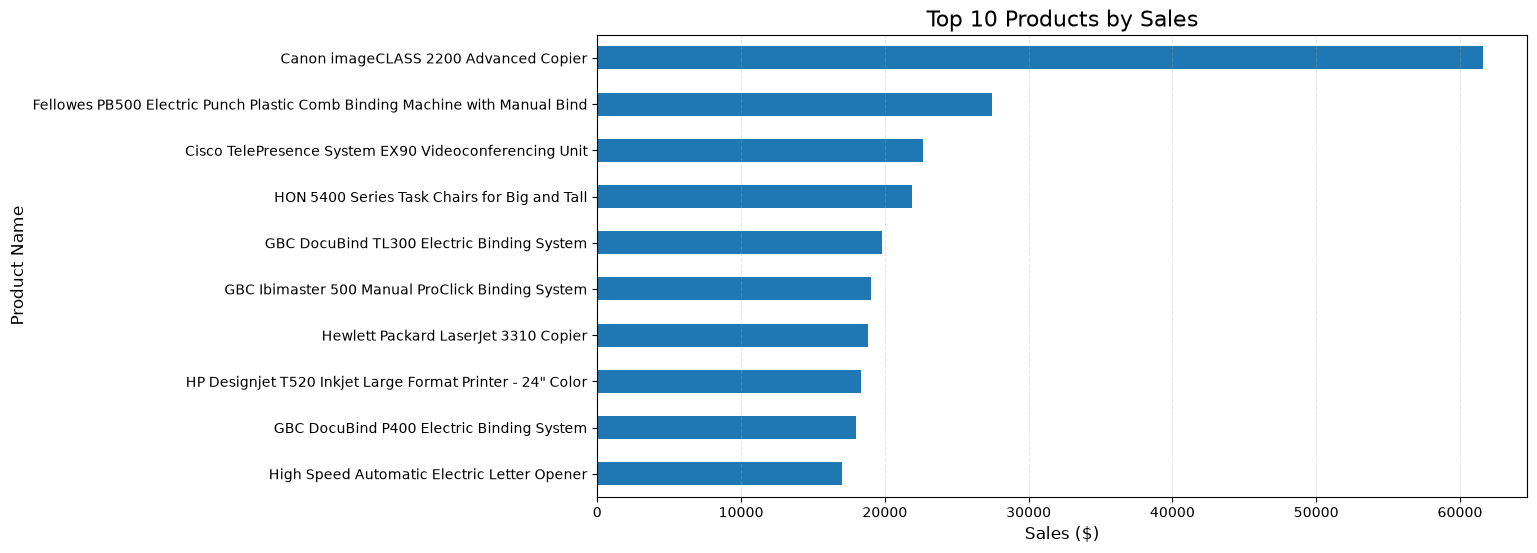

In [97]:
plt.figure(figsize=(12, 6))

top_product_sales.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Sales",fontsize=16)
plt.xlabel("Sales ($)",fontsize=12)
plt.ylabel("Product Name",fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

In [98]:
top_product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_product_profit.to_frame(name="Total Profit")

,Total Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


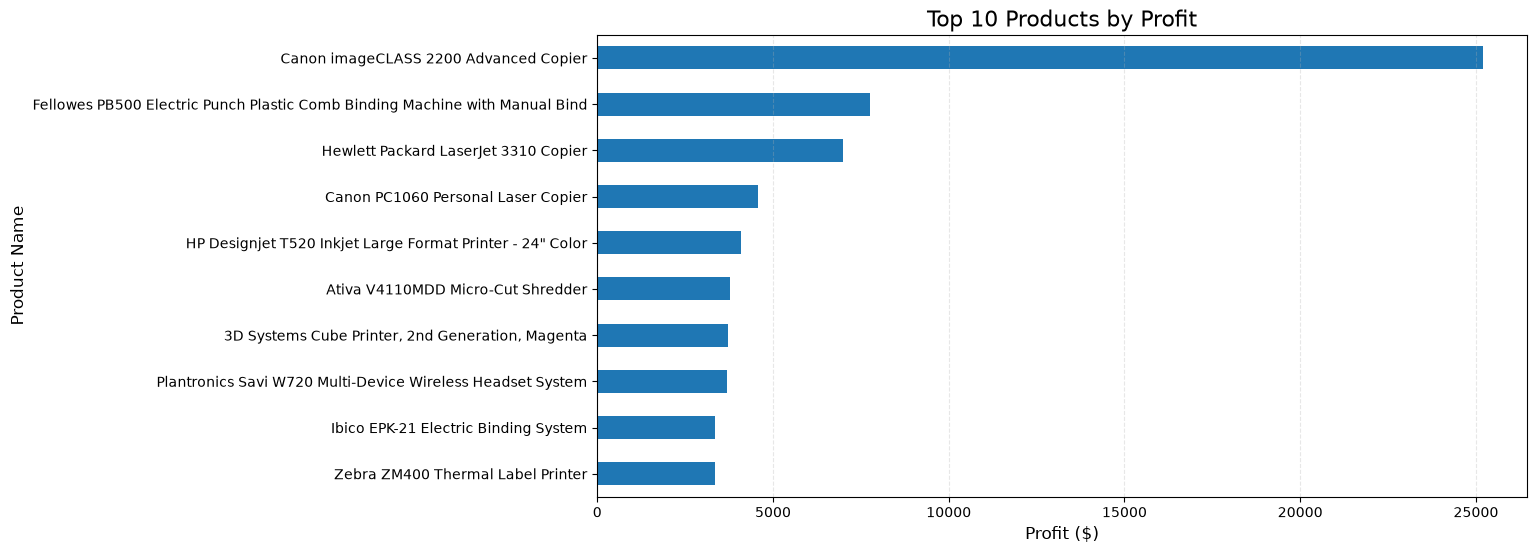

In [99]:
plt.figure(figsize=(12, 6))

top_product_profit.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Profit",fontsize=16)
plt.xlabel("Profit ($)",fontsize=12)
plt.ylabel("Product Name",fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

In [100]:
bottom_products_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values()
      .head(10)
)

bottom_products_profit.to_frame(name="Total Profit")

,Total Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


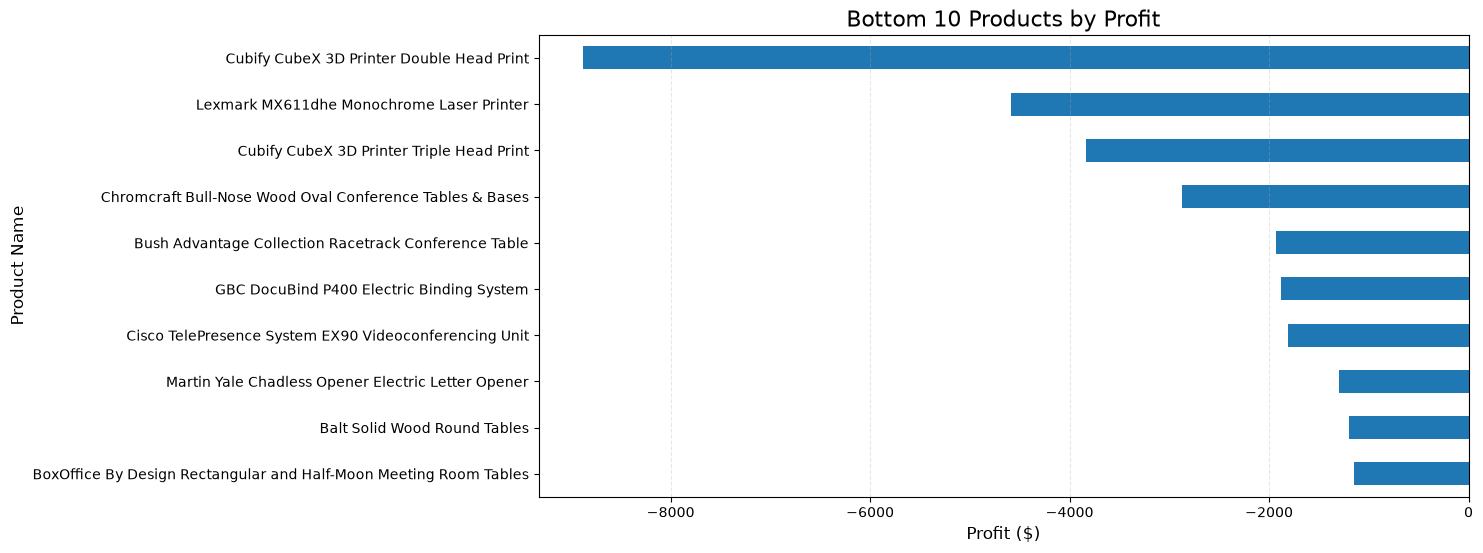

In [101]:
plt.figure(figsize=(12, 6))

bottom_products_profit.sort_values(ascending=False).plot(
    kind="barh"
)

plt.title("Bottom 10 Products by Profit", fontsize=16)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

In [102]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .agg(["sum","mean","count"])
)

discount_profit

,sum,mean,count
Discount,,,
0.00,326718.5872,66.338799,4925
0.10,9099.9700,94.791354,96
0.15,1418.9915,27.288298,52
0.20,91079.9517,24.576350,3706
0.30,-10513.4456,-45.710633,230
0.32,-2391.1377,-88.560656,27
0.40,-23086.3742,-111.528378,207
0.45,-2493.1111,-226.646464,11
0.50,-20506.4281,-310.703456,66


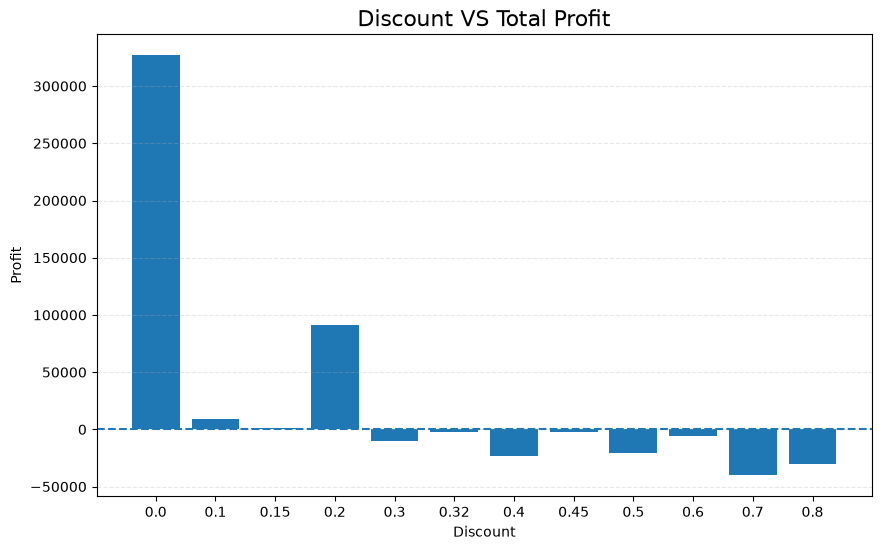

In [104]:
plt.figure(figsize=(10, 6))

plt.bar(
    discount_profit.index.astype(str),
    discount_profit["sum"]
)

plt.axhline(0, linestyle="--")

plt.title("Discount VS Total Profit",fontsize=16)
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
## Busniess Insights

There is a clear relationship between high discounts and poor profitability.

Especially:

Discounts of 30% and above are associated with negative total profit.

The 70% discount level produces the largest total loss: approximately $40,301.

However, be careful saying "discount directly causes the loss" because this analysis alone shows association, not causation. Other factors such as product category, region, and product cost may also contribute.

One interesting point

20% discount still has +$91,079.95 profit, so we shouldn't conclude that all discounts are bad.

A better dashboard insight would be:

Moderate discounts can remain profitable, while higher discount levels are strongly associated with negative profitability.

In [105]:
quantity_analysis = (
    df.groupby("Quantity")[["Sales", "Profit"]]
        .agg(["sum", "mean", "count"])
)

quantity_analysis

Sales                         Profit                  
                  sum         mean count         sum        mean count
Quantity                                                              
1          55477.0705    59.460954   933   7784.2896    8.343290   933
2         294356.4678   120.637897  2440  39419.8532   16.155678  2440
3         424587.8447   174.368725  2435  57495.8890   23.612275  2435
4         334265.1444   275.796324  1212  46293.4976   38.195955  1212
5         416989.8365   328.597192  1269  49669.5585   39.140708  1269
6         207807.3294   355.226204   585  10568.2474   18.065380   585
7         241906.2919   392.068544   617  35172.7534   57.006083   617
8         120704.4780   448.715532   269  11244.0092   41.799291   269
9         129369.2301   499.495097   259  17795.8458   68.709829   259
10         24894.6640   408.109246    61   2278.7970   37.357328    61
11         15772.4820   463.896529    34   4293.3671  126.275503    34
12         14868.4080   646.452522    23   1185.0660   51.524609    23
13         32338.1890  1197.710704    27   6348.9010  235.144481    27
14         13196.9180   439.897267    30   2746.7398   91.557993    30

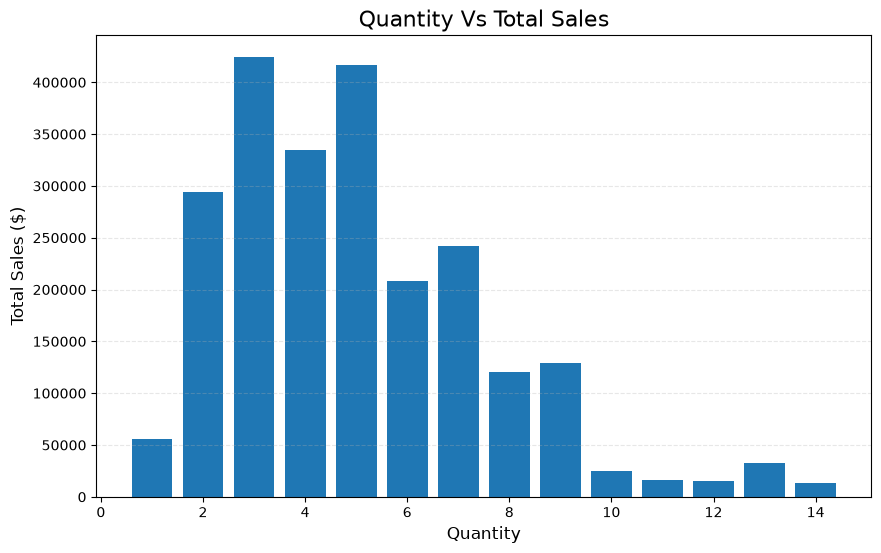

In [106]:
plt.figure(figsize=(10, 6))

quantity_sales = df.groupby("Quantity")["Sales"].sum()

plt.bar(
    quantity_sales.index,
    quantity_sales.values
)

plt.title("Quantity Vs Total Sales",fontsize=16)
plt.xlabel("Quantity",fontsize=12)
plt.ylabel("Total Sales ($)",fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
#Business Insights

Higher quantity generally produces higher revenue and profit per order line.

However, don't say that quantity causes higher profit. Larger quantities naturally create larger transactions, so this is mainly a transaction-size relationship.

Also notice something important:

Quantity 3 generates the highest total sales.
Quantity 5 generates almost as much.
Quantities 10–14 have much fewer records.

For example, quantity 13 has an impressive average profit of $235.14, but there are only 27 records, so we shouldn't treat it as a major business segment.

In [107]:
ship_mode_analysis = (
    df.groupby("Ship Mode")[["Sales", "Profit"]]
    .agg(["sum", "mean","count"])
)

ship_mode_analysis

Sales                         Profit                 
                         sum        mean count          sum       mean count
Ship Mode                                                                   
First Class     3.517507e+05  227.229158  1548   49012.7242  31.661967  1548
Same Day        1.292720e+05  236.328985   547   16160.7480  29.544329   547
Second Class    4.666711e+05  235.811577  1979   58962.1329  29.793902  1979
Standard Class  1.378841e+06  225.300744  6120  168161.2095  27.477322  6120

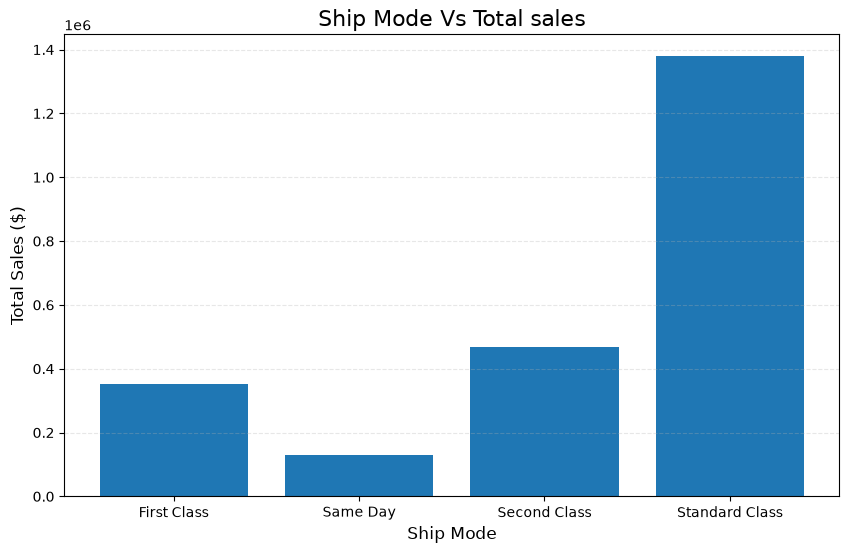

In [108]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum()

plt.figure(figsize=(10, 6))

plt.bar(
    ship_sales.index,
    ship_sales.values
)

plt.title("Ship Mode Vs Total sales",fontsize=16)
plt.xlabel("Ship Mode",fontsize=12)
plt.ylabel("Total Sales ($)",fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

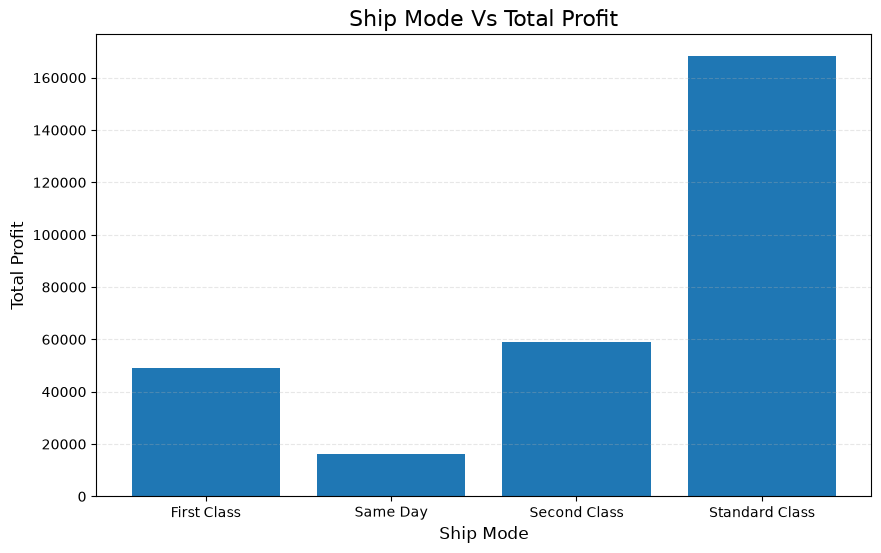

In [109]:
ship_profit = df.groupby("Ship Mode")["Profit"].sum()

plt.figure(figsize=(10, 6))

plt.bar(
    ship_profit.index,
    ship_profit.values
)

plt.title("Ship Mode Vs Total Profit",fontsize=16)
plt.xlabel("Ship Mode",fontsize=12)
plt.ylabel("Total Profit",fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
## Business Insights

1. Standard Class dominates the business.
It has by far the highest sales and profit, mainly because it has the highest number of orders.

2. Same Day has the lowest overall sales and profit.
But that doesn't necessarily mean Same Day is a bad shipping method—it simply has far fewer orders.

3. Average profit is actually quite similar.

First Class → $31.66/order
Same Day → $29.54/order
Second Class → $29.79/order
Standard Class → $27.48/order

That's an interesting insight:

Standard Class generates the most total profit because of its much larger order volume, not because it has the highest profit per order.

This is a much better business insight than simply saying "Standard Class is the best."

In [118]:
segment_analysis = (
    df.groupby("Segment")[["Sales", "Profit"]]
    .agg(["sum","mean","count"])
)

segment_analysis

Sales                         Profit                 
                      sum        mean count          sum       mean count
Segment                                                                  
Consumer     1.170660e+06  221.673885  5281  136371.4463  25.823035  5281
Corporate    7.158061e+05  231.652471  3090   94249.6400  30.501502  3090
Home Office  4.400684e+05  241.397933  1823   61675.7283  33.831996  1823

In [ ]:
## Business Insights

1. Consumer is the largest segment.
It generates the most sales and total profit because it has the largest number of orders.

2. Home Office is the most profitable per order.
Although it has the lowest sales volume, each order generates about $33.83 profit, compared with $25.82 for Consumer.

3. Corporate is in the middle.
It has considerably fewer orders than Consumer but generates a higher profit per order.

4. This gives us an important dashboard insight:

Sales volume ≠ profitability.

Consumer is the biggest revenue contributor, but Home Office has the strongest profitability per order.

In [119]:
customer_analysis = (
    df.groupby("Customer Name")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

customer_analysis.head(10)

,Sales,Profit
Customer Name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
Ken Lonsdale,14175.229,806.8550
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Sanjit Engle,12209.438,2650.6769


In [ ]:
## Busniess Insights

Sean Miller is the biggest warning.

He generated:

Sales: $25,043
Profit: -$1,981

So the customer with the highest sales among these customers is actually generating a loss.

That's exactly the type of insight we want from a Sales Performance Dashboard.

For example:

"High-revenue customers are not necessarily high-profit customers."

This can lead to investigating discounts, product mix, shipping costs, or loss-making products associated with that customer.

In [121]:
top_customer_profit = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customer_profit.to_frame("Total Profit")

,Total Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


In [122]:
bottom_customer_profit = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

bottom_customer_profit.to_frame("Total Profit")

,Total Profit
Customer Name,
Cindy Stewart,-6626.3895
Grant Thornton,-4108.6589
Luke Foster,-3583.9770
Sharelle Roach,-3333.9144
Henry Goldwyn,-2797.9635
Nathan Cano,-2204.8072
Sean Braxton,-2082.7451
Sean Miller,-1980.7393
Christine Phan,-1850.3029


In [ ]:
## Business Insights

1. Cindy Stewart is the biggest loss-making customer

Profit = -$6,626.39

2. Sean Miller is particularly interesting
From our previous analysis:

Sales = $25,043.05
Profit = -$1,980.74

So Sean Miller has high sales but negative profit.

3. Tamara Chand is an excellent customer

Sales = $19,052.22
Profit = $8,981.32

This is exactly the kind of customer the business wants: strong sales + strong profitability.

In [124]:
category_analysis = (
    df.groupby("Category")[["Sales", "Profit"]]
    .agg(["sum","mean","count"])
)

category_analysis

Sales                         Profit                 
                         sum        mean count          sum       mean count
Category                                                                    
Furniture        754747.7613  342.911295  2201   19729.9956   8.964105  2201
Office Supplies  731893.3140  119.434288  6128  126023.4434  20.565183  6128
Technology       839893.2790  450.344922  1865  146543.3756  78.575537  1865

In [ ]:
## Busniess Insights

🥇 Technology is the strongest category

Highest Sales: $839.9K
Highest Profit: $146.5K
Highest profit margin: 17.45%

🥈 Office Supplies

Sales are slightly lower than Furniture.
But it generates $126K profit, far more than Furniture.

⚠️ Furniture needs attention

Sales: $754.7K
Profit: only $19.7K
Margin: only 2.61%

So an important dashboard insight is:

Furniture generates substantial sales but very little profit compared with Technology and Office Supplies.

This is a very useful business finding because it tells management where revenue is coming from vs. where profitability is coming from.

In [126]:
subcategory_analysis = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .agg(["sum","mean","count"])
)

subcategory_analysis

Sales                         Profit                  
                      sum         mean count         sum        mean count
Sub-Category                                                              
Accessories   167380.3180   215.974604   775  41936.6357   54.111788   775
Appliances    108213.1850   228.297859   474  18329.4844   38.669798   474
Art            27659.0140    33.689420   821   6653.1962    8.103771   821
Binders       207354.8810   133.950182  1548  31426.1003   20.301098  1548
Bookcases     115361.2043   497.246570   232  -3632.0736  -15.655490   232
Chairs        335768.2490   529.602916   634  27223.5323   42.939325   634
Copiers       150745.2900  2153.504143    70  56093.9365  801.341950    70
Envelopes      16528.3620    64.563914   256   6988.0247   27.296971   256
Fasteners       8532.2400    37.258690   229   2428.6358   10.605397   229
Furnishings    95598.1260    94.745417  1009  13891.7430   13.767833  1009
Labels         12695.0420    34.497397   368   5572.7780   15.143418   368
Machines      189925.0310  1623.290863   117   3461.9769   29.589546   117
Paper          79540.5380    57.471487  1384  34511.5070   24.936060  1384
Phones        331842.6400   367.489081   903  45050.8265   49.890173   903
Storage       224644.5540   262.435227   856  21285.1115   24.865784   856
Supplies       46725.4980   243.361969   192  -1171.3945   -6.101013   192
Tables        208020.1820   638.098718   326 -17753.2061  -54.457687   326

In [127]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit.to_frame(name="Total Profit")

,Total Profit
Sub-Category,
Copiers,56093.9365
Phones,45050.8265
Accessories,41936.6357
Paper,34511.5070
Binders,31426.1003
Chairs,27223.5323
Storage,21285.1115
Appliances,18329.4844
Furnishings,13891.7430


In [132]:
subcategory_profit.sort_values().head(10).to_frame(name="Total Profit")

,Total Profit
Sub-Category,
Tables,-17753.2061
Bookcases,-3632.0736
Supplies,-1171.3945
Fasteners,2428.6358
Machines,3461.9769
Labels,5572.7780
Art,6653.1962
Envelopes,6988.0247
Furnishings,13891.7430


In [ ]:
A particularly useful comparison

Look at:

Chairs

Sales: $335,768
Profit: $27,224

versus:

Tables

Sales: $208,020
Profit: -$17,753

Both are Furniture sub-categories, but their profitability is dramatically different.

So management shouldn't simply say:

"Furniture is performing poorly."

Instead:

"Furniture profitability is being dragged down primarily by Tables and Bookcases, while Chairs remain profitable."

That's a much stronger analyst-level insight.

In [133]:
region_analysis = (
    df.groupby("Region")[["Sales","Profit"]]
    .agg(["sum","mean","count"])
)

region_analysis

Sales                         Profit                 
                 sum        mean count          sum       mean count
Region                                                              
Central  503170.6728  215.490652  2335   39865.3070  17.072937  2335
East     691828.1680  231.690612  2986   94883.2603  31.776042  2986
South    391721.9050  241.803645  1620   46749.4303  28.857673  1620
West     739813.6085  227.425026  3253  110798.8170  34.060503  3253

In [136]:
region_summary = (
    df.groupby("Region")[["Sales","Profit"]]
    .sum()
)

region_summary["Profit Margin (%)"] = (
    region_summary["Profit"]
    / region_summary["Sales"] * 100
)

region_summary.sort_values(
    "Profit",
    ascending=False
)

region_summary

,Sales,Profit,Profit Margin (%)
Region,,,
Central,503170.6728,39865.3070,7.922820
East,691828.1680,94883.2603,13.714859
South,391721.9050,46749.4303,11.934342
West,739813.6085,110798.8170,14.976585


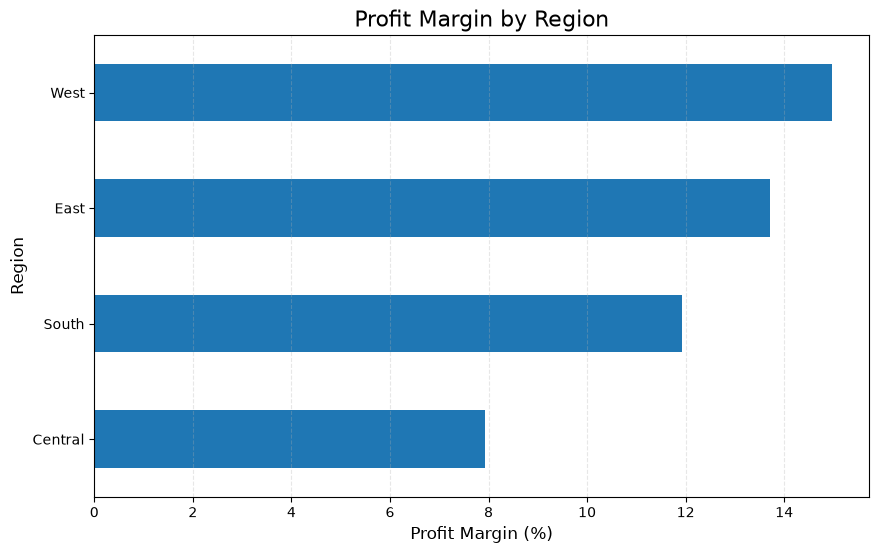

In [138]:
plt.figure(figsize=(10, 6))

region_summary["Profit Margin (%)"].sort_values().plot(
    kind="barh"
)

plt.title("Profit Margin by Region",fontsize=16)
plt.xlabel("Profit Margin (%)",fontsize=12)
plt.ylabel("Region",fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
🥇 West is the strongest region

Highest sales: $739.8K
Highest profit: $110.8K
Highest margin: 14.98%

🥈 East is also performing strongly

$691.8K sales
$94.9K profit
13.71% margin

⚠️ Central needs attention

$503.2K sales
Only $39.9K profit
Lowest margin: 7.92%

This is another important dashboard insight:

Central generates more sales than South, but its profitability is significantly weaker.

So we should investigate what's happening in Central—particularly discounts, categories, and sub-categories.

In [139]:
correlation = (
    df[["Sales", "Profit", "Quantity", "Discount"]]
    .corr()
)

correlation

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.481460,0.198457,-0.027756
Profit,0.481460,1.000000,0.066145,-0.218882
Quantity,0.198457,0.066145,1.000000,0.007475
Discount,-0.027756,-0.218882,0.007475,1.000000


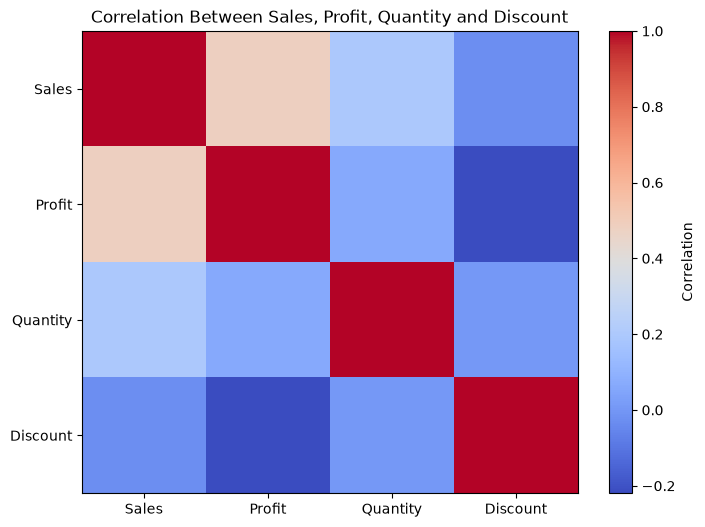

In [140]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Sales, Profit, Quantity and Discount")

plt.show()

In [ ]:
Discount ↔ Profit = -0.219

This supports what we already discovered in the Discount Analysis:

Higher discounts tend to be associated with lower profitability.

It's not a strong linear relationship, so we shouldn't claim that discount alone causes losses. But combined with our earlier finding that discounts of 30% and above produced negative total profit, it is a strong area for business investigation.

Another important finding

Sales ↔ Profit = 0.481

There is a moderate positive relationship, meaning higher sales generally tend to accompany higher profit—but sales alone don't guarantee profitability.

Our earlier examples prove this:

Sean Miller → high sales but negative profit
Tables → $208K sales but -$17.75K profit
Furniture → $754.7K sales but only $19.7K profit

That's a very strong story for the dashboard.

In [142]:
kpi = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Total Quantity": df["Quantity"].sum(),
    "Profit Margin (%)": df["Profit"].sum() / df["Sales"].sum() * 100,
    "Average Order Value": df["Sales"].sum() / df["Order ID"].nunique(),
    "Average Discount (%)": df["Discount"].mean() * 100,
    "Total Customers": df["Customer Name"].nunique(),
    "Total Products": df["Product Name"].nunique()
}

kpi

{'Total Sales': np.float64(2326534.3543),
 'Total Profit': np.float64(292296.8145999999),
 'Total Orders': 5111,
 'Total Quantity': np.int64(38654),
 'Profit Margin (%)': np.float64(12.563614805849074),
 'Average Order Value': np.float64(455.2013997847779),
 'Average Discount (%)': np.float64(15.538453992544635),
 'Total Customers': 800,
 'Total Products': 1849}

In [ ]:
# Final Business Insights

Based on the complete Exploratory Data Analysis (EDA), the following key business insights were identified:

### 1. Overall Sales Performance
- Total sales generated are approximately **$2.33 million**, with a total profit of approximately **$292.30K**.
- The overall profit margin is **12.56%**, indicating that the business is profitable overall.
- Sales showed strong growth in the later years, with annual sales increasing from approximately **$614K in 2025 to $746K in 2026**.

### 2. Category Performance
- **Technology** is the strongest-performing category, generating approximately **$839.89K in sales** and **$146.54K in profit**, with a profit margin of approximately **17.45%**.
- **Office Supplies** generated approximately **$731.89K in sales** and **$126.02K in profit**.
- **Furniture** generated approximately **$754.75K in sales**, but only **$19.73K in profit**, resulting in a low profit margin of approximately **2.61%**.
- Therefore, Furniture requires profitability improvement despite having substantial sales.

### 3. Sub-Category Performance
- **Copiers** generated the highest profit at approximately **$56.09K**, followed by **Phones ($45.05K)** and **Accessories ($41.94K)**.
- **Tables** are the largest loss-making sub-category, generating approximately **$208.02K in sales but a loss of $17.75K**.
- **Bookcases** and **Supplies** also generated negative profits.
- The results show that high sales do not necessarily translate into high profitability.

### 4. Regional Performance
- **West** is the strongest region, generating approximately **$739.81K in sales**, **$110.80K in profit**, and the highest profit margin of **14.98%**.
- **East** is the second strongest region, with a profit margin of approximately **13.71%**.
- **Central** has the lowest profit margin at approximately **7.92%**, despite generating more sales than the South region.
- Central therefore requires further investigation into pricing, discounts, and product profitability.

### 5. Customer Profitability
- **Tamara Chand** is the most profitable customer, generating approximately **$8.98K in profit**.
- **Cindy Stewart** is the largest loss-making customer, generating approximately **-$6.63K in profit**.
- **Sean Miller** is an important example of why sales alone should not be used to evaluate customers: the customer generated approximately **$25.04K in sales but a loss of $1.98K**.
- Customer profitability should therefore be considered alongside sales when making business decisions.

### 6. Discount Impact
- Discount and Profit have a negative correlation of approximately **-0.219**, indicating a weak negative relationship.
- The discount analysis also showed that higher discount levels can result in negative total profits.
- Therefore, excessive discounting should be carefully controlled to protect profitability.

### 7. Quantity and Sales Relationship
- Sales and Quantity have a weak positive correlation of approximately **0.198**.
- This indicates that selling more units does not necessarily result in proportionally higher sales.
- Product price, product mix, and discount levels also influence overall sales performance.

### 8. Sales and Profit Relationship
- Sales and Profit have a moderate positive correlation of approximately **0.481**.
- This indicates that higher sales generally contribute to higher profits, but sales alone do not guarantee profitability.
- Loss-making products, customers, regions, and excessive discounts can reduce profitability even when sales are high.

### 9. Key Business Recommendation
- Focus on expanding **Technology** and other highly profitable product categories.
- Review pricing, discounting, and costs for **Furniture**, especially **Tables and Bookcases**.
- Investigate the low profitability of the **Central region**.
- Identify and review customers generating high sales but low or negative profits.
- Use both **Sales and Profit** KPIs rather than relying on sales alone when evaluating business performance.
- Maintain controlled discount strategies to improve overall profit margins.

### 10. Overall Conclusion
The analysis shows that the business has strong overall sales and profitability, but performance varies significantly across products, categories, customers, and regions. The major opportunity is to shift focus from revenue-only analysis toward **profitability-driven decision making**. The Sales Performance Dashboard will provide an interactive view of these KPIs and help identify profitable areas, underperforming segments, and opportunities for improvement.